
GLOBAL VALIDATION METRICS


,variant,acc,precision_macro,recall_macro,f1_macro,logloss,mcc,kappa,auc_roc_macro_ovr,pr_auc_macro
0,High Class-Entropy Datasets,0.9493,0.9320,0.8386,0.8765,0.1840,0.7641,0.7536,0.9755,0.8718
1,Large Datasets Only,0.9771,0.9769,0.9442,0.9516,0.0628,0.9168,0.9110,0.9908,0.9589
2,Extreme Non-IID Dirichlet Split,0.9162,0.4769,0.5180,0.4956,0.7656,0.0335,0.0329,0.9667,0.9195
3,Moderate Non-IID Dirichlet Split,0.9833,0.9796,0.9518,0.9628,0.0579,0.9296,0.9260,0.9903,0.9543
4,Near-IID Client Split (Control),0.9845,0.9806,0.9531,0.9638,0.0467,0.9318,0.9280,0.9954,0.9681



GLOBAL TEST METRICS


,variant,acc,precision_macro,recall_macro,f1_macro,logloss,mcc,kappa,auc_roc_macro_ovr,pr_auc_macro
0,High Class-Entropy Datasets,0.9473,0.9302,0.8252,0.8665,0.1882,0.7470,0.7338,0.9742,0.8628
1,Large Datasets Only,0.9765,0.9768,0.9405,0.9488,0.0651,0.9122,0.9055,0.9909,0.9574
2,Extreme Non-IID Dirichlet Split,0.9163,0.4770,0.5178,0.4956,0.7708,0.0336,0.0329,0.9627,0.9126
3,Moderate Non-IID Dirichlet Split,0.9830,0.9793,0.9483,0.9602,0.0589,0.9252,0.9209,0.9899,0.9516
4,Near-IID Client Split (Control),0.9837,0.9796,0.9488,0.9605,0.0478,0.9261,0.9215,0.9950,0.9654


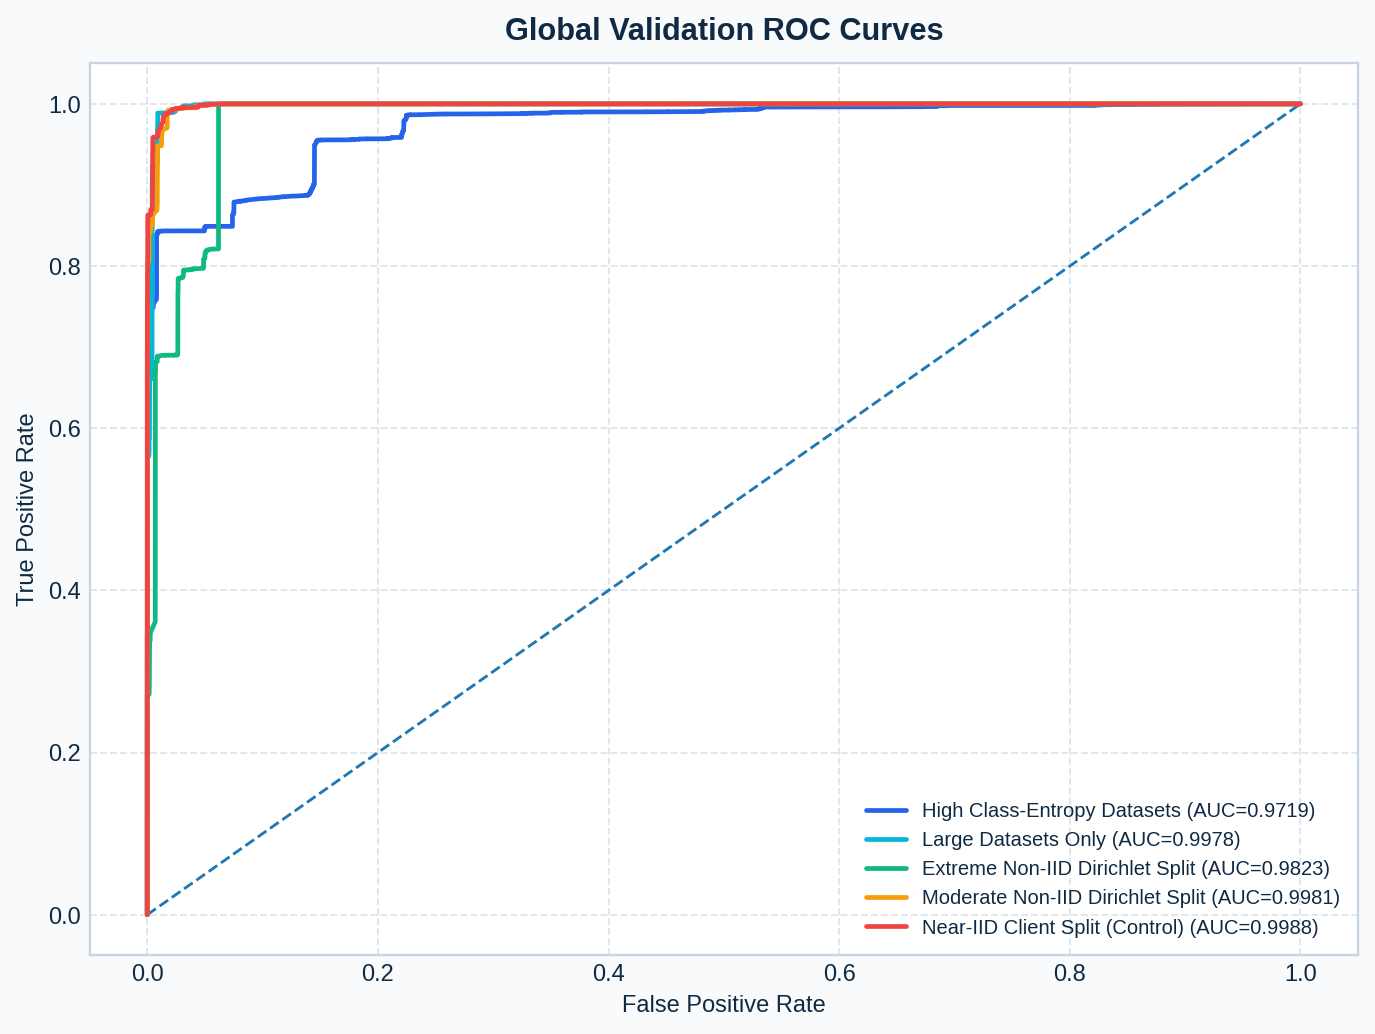

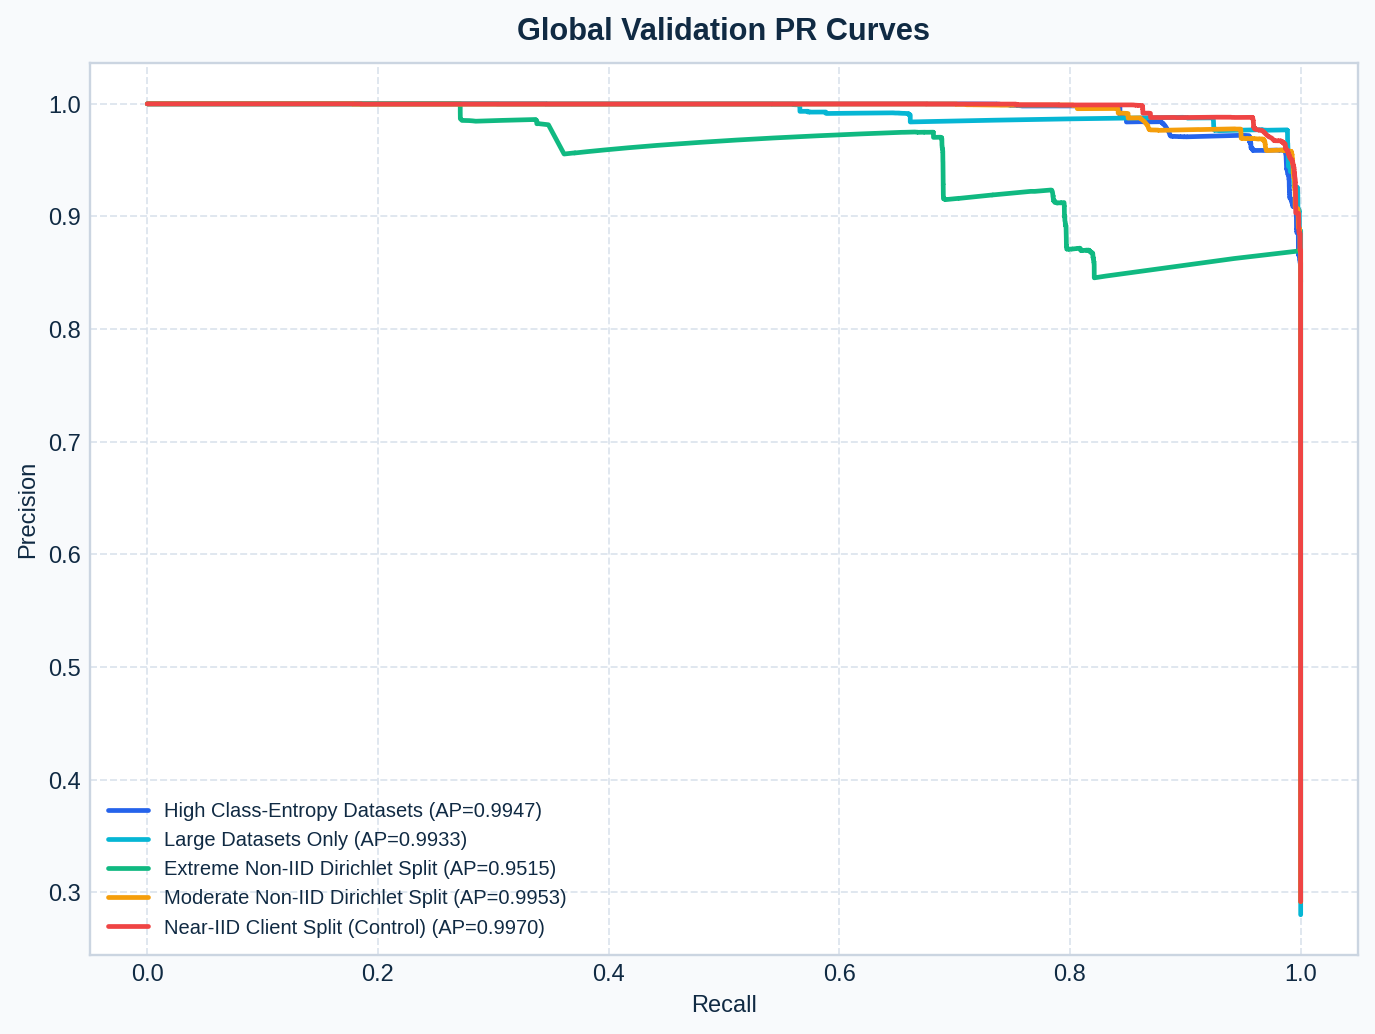

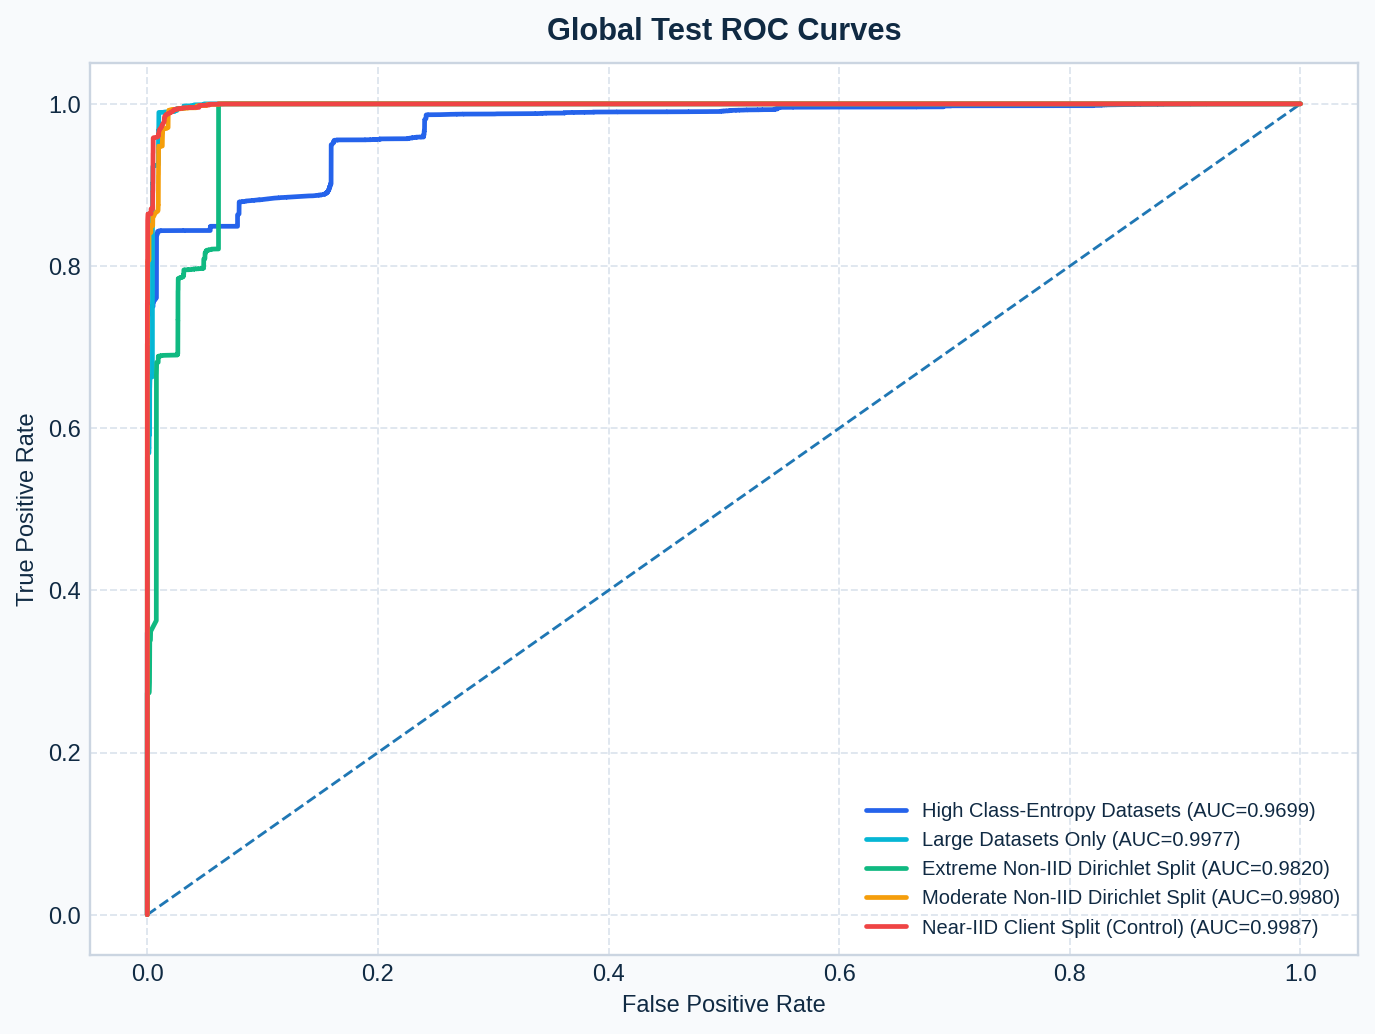

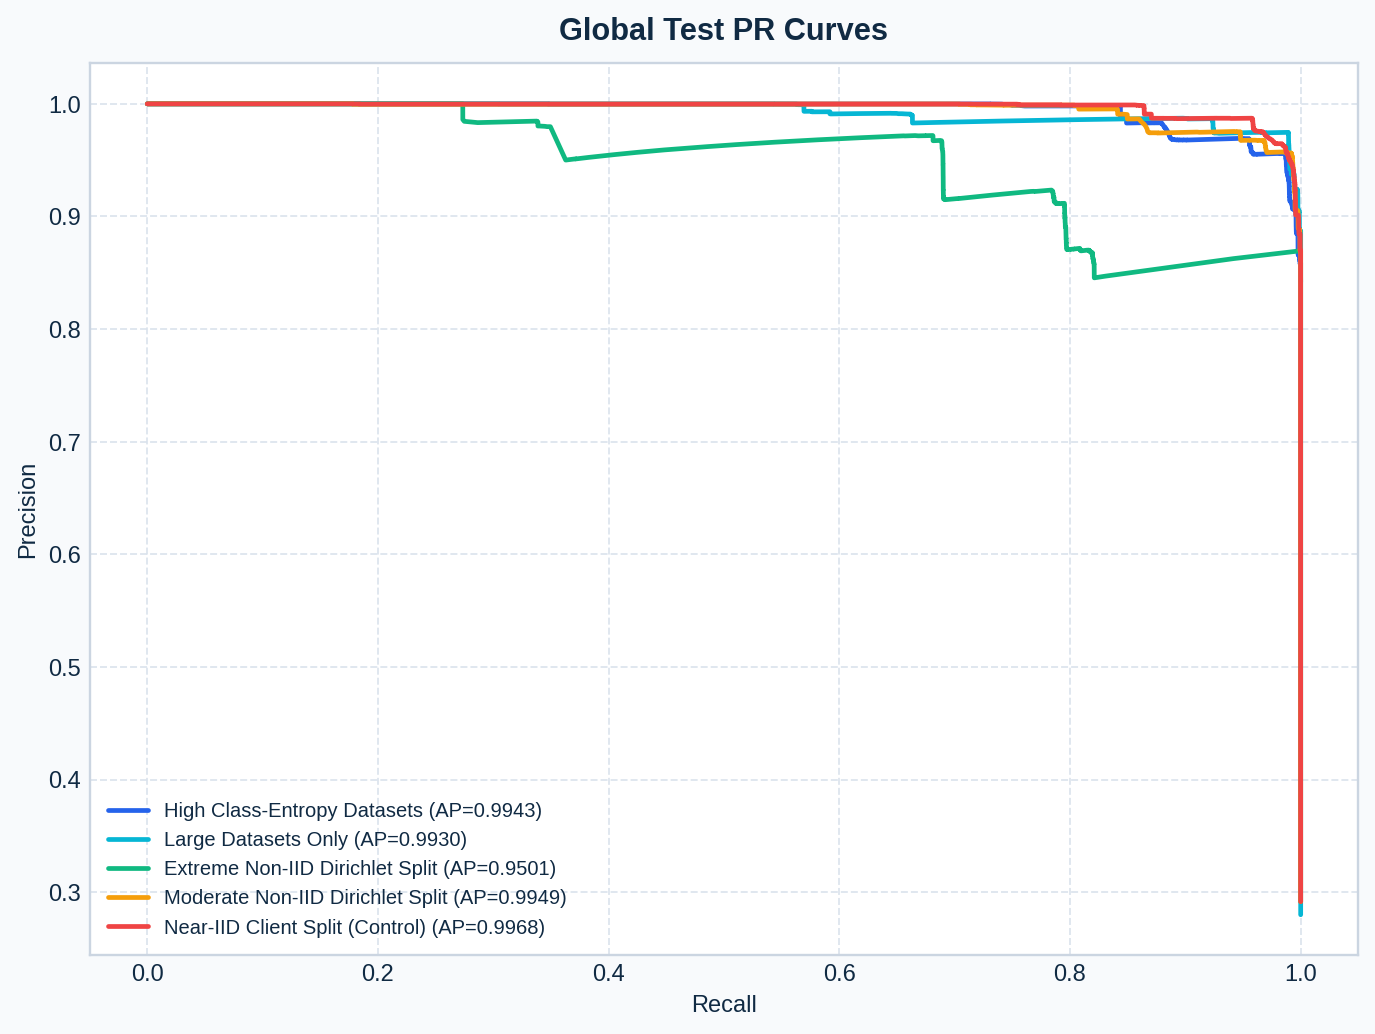

In [ ]:
def vprint(*args, **kwargs):
    return None

import os
import gc
import re
import glob
import json
import time
import math
import random
import warnings
import zlib
from io import BytesIO
from html import escape as html_escape
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
try:
    from IPython.display import display, Image as IPImage, HTML
    IN_NOTEBOOK = True
except Exception:
    HTML = None
    IN_NOTEBOOK = False
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, log_loss, matthews_corrcoef, roc_auc_score, confusion_matrix, roc_curve, average_precision_score, precision_recall_curve, cohen_kappa_score
from sklearn.preprocessing import label_binarize
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PIN_MEM = DEVICE == 'cuda'
NUM_WORKERS = 2 if DEVICE == 'cuda' else 0
BG_CLR = '#f8fafc'
PANEL_CLR = '#ffffff'
GRID_CLR = '#d9e2ec'
TEXT_CLR = '#102a43'
SUBTEXT_CLR = '#486581'
ACCENT_1 = '#2563eb'
ACCENT_2 = '#06b6d4'
ACCENT_3 = '#10b981'
ACCENT_4 = '#f97316'
ACCENT_5 = '#ef4444'
ACCENT_6 = '#8b5cf6'
PALETTE = ['#2563eb', '#06b6d4', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6', '#0ea5e9', '#22c55e', '#f97316', '#db2777', '#84cc16', '#7c3aed']
PROCESS_NAME = 'GRIP-DFFI'
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.facecolor': BG_CLR, 'axes.facecolor': PANEL_CLR, 'savefig.facecolor': BG_CLR, 'axes.edgecolor': '#cbd5e1', 'axes.labelcolor': TEXT_CLR, 'xtick.color': TEXT_CLR, 'ytick.color': TEXT_CLR, 'text.color': TEXT_CLR, 'axes.titlecolor': TEXT_CLR, 'grid.color': GRID_CLR, 'grid.linestyle': '--', 'grid.linewidth': 0.8, 'axes.grid': True, 'font.size': 10, 'axes.titlesize': 13, 'axes.titleweight': 'bold', 'legend.framealpha': 0.96, 'legend.facecolor': 'white', 'legend.edgecolor': '#d1d5db'})
SPLIT_POLICY = 'merge-compatible-labeled-sources-then-fresh-split'
PRESERVE_OFFICIAL_BENCHMARK_SPLITS = False

def save_or_show(fig, path=None):
    fig.tight_layout()
    if path is not None:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        fig.savefig(path, dpi=180, bbox_inches='tight')
    if IN_NOTEBOOK:
        buf = BytesIO()
        fig.savefig(buf, format='png', dpi=170, bbox_inches='tight')
        buf.seek(0)
        display(IPImage(data=buf.read()))
    plt.close(fig)

def prettify_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(PANEL_CLR)
    for sp in ax.spines.values():
        sp.set_edgecolor('#cbd5e1')
    ax.grid(True, color=GRID_CLR, linestyle='--', linewidth=0.8, alpha=0.85)
    ax.tick_params(colors=TEXT_CLR)
    if title is not None:
        ax.set_title(title, pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
_TABLE_CSS_EMITTED = False

def _emit_table_css_once():
    global _TABLE_CSS_EMITTED
    if not IN_NOTEBOOK or _TABLE_CSS_EMITTED:
        return
    css = '\n    <style>\n      .grip-table-block {\n        margin: 12px 0 18px 0;\n        border: 1px solid #dbe4ee;\n        border-radius: 12px;\n        overflow-x: auto;\n        background: #ffffff;\n        box-shadow: 0 1px 4px rgba(15, 23, 42, 0.05);\n      }\n      .grip-table-title {\n        padding: 10px 14px;\n        font-weight: 700;\n        color: #0f172a;\n        background: #f8fafc;\n        border-bottom: 1px solid #e2e8f0;\n        font-size: 15px;\n      }\n      .grip-table-block table.dataframe {\n        border-collapse: separate !important;\n        border-spacing: 0;\n        width: max-content;\n        min-width: 100%;\n        margin: 0;\n        font-size: 13px;\n      }\n      .grip-table-block table.dataframe thead th {\n        position: sticky;\n        top: 0;\n        background: #eff6ff;\n        color: #0f172a;\n        text-align: left;\n        padding: 9px 10px;\n        border-bottom: 1px solid #cbd5e1;\n        white-space: nowrap;\n      }\n      .grip-table-block table.dataframe tbody td {\n        padding: 8px 10px;\n        border-bottom: 1px solid #eef2f7;\n        vertical-align: top;\n        white-space: normal;\n        word-break: break-word;\n      }\n      .grip-table-block table.dataframe tbody tr:nth-child(even) {\n        background: #fcfdff;\n      }\n      .grip-table-block table.dataframe tbody tr:hover {\n        background: #f8fbff;\n      }\n      .grip-note {\n        color: #475569;\n        font-size: 12px;\n        margin: 6px 0 12px 2px;\n      }\n    </style>\n    '
    display(HTML(css))
    _TABLE_CSS_EMITTED = True

def wrap_sequence_for_display(seq, items_per_line=8):
    seq = list(seq)
    if not seq:
        return '[]'
    lines = []
    for i in range(0, len(seq), items_per_line):
        chunk = ', '.join((str(x) for x in seq[i:i + items_per_line]))
        lines.append(chunk)
    return '[' + ',\n '.join(lines) + ']'

def _prepare_table_df(df, float_decimals=4):
    out = df.copy()
    for col in out.columns:
        vals = []
        for v in out[col].tolist():
            if isinstance(v, (list, tuple, np.ndarray)):
                vals.append(wrap_sequence_for_display(v))
            elif isinstance(v, (float, np.floating)):
                vals.append('' if pd.isna(v) else f'{float(v):.{float_decimals}f}')
            elif isinstance(v, (int, np.integer)) and (not isinstance(v, (bool, np.bool_))):
                vals.append(f'{int(v):,}')
            elif isinstance(v, (bool, np.bool_)):
                vals.append('True' if bool(v) else 'False')
            elif pd.isna(v):
                vals.append('')
            else:
                vals.append(str(v))
        out[col] = vals
    return out

def show_table(title, df, index=False, rename_map=None, columns=None, float_decimals=4, note=None):
    if df is None:
        return
    view = df.copy()
    if columns is not None:
        existing = [c for c in columns if c in view.columns]
        view = view[existing]
    if rename_map is not None:
        view = view.rename(columns=rename_map)
    view = _prepare_table_df(view, float_decimals=float_decimals)
    if IN_NOTEBOOK:
        _emit_table_css_once()
        html_df = view.copy()
        html_df.columns = [html_escape(str(c)) for c in html_df.columns]
        for col in html_df.columns:
            html_df[col] = html_df[col].map(lambda s: html_escape(str(s)).replace('\n', '<br>'))
        table_html = html_df.to_html(index=index, escape=False, border=0)
        note_html = f'<div class="grip-note">{html_escape(str(note))}</div>' if note else ''
        display(HTML(f'<div class="grip-table-block"><div class="grip-table-title">{html_escape(str(title))}</div>{table_html}</div>{note_html}'))
    else:
        print('\n' + '=' * 100)
        print(title)
        print('-' * 100)
        try:
            print(view.to_markdown(index=index))
        except Exception:
            print(view.to_string(index=index))
        if note:
            print(note)
        print('=' * 100)

def show_key_value_table(title, items, note=None):
    df = pd.DataFrame({'Field': list(items.keys()), 'Value': [wrap_sequence_for_display(v) if isinstance(v, (list, tuple, np.ndarray)) else v for v in items.values()]})
    show_table(title, df, index=False, float_decimals=4, note=note)
DATASET_SPECS = [{'name': 'I23Sub', 'source_type': 'kaggle', 'slug': 'wittigenz/hydras', 'domain_id': 0, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class_type'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack', 'Class'], 'normal_aliases': ['normal', 'benign', 'benign_traffic', 'background', 'legitimate', '0'], 'file_rank': None, 'unsw_nb15_raw': False}, {'name': 'K99Sub', 'source_type': 'kaggle', 'slug': 'sampadab17/network-intrusion-detection', 'domain_id': 1, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class', 'Class'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack'], 'normal_aliases': ['normal', 'benign', '0'], 'file_rank': None, 'unsw_nb15_raw': False}, {'name': 'NTD1', 'source_type': 'kaggle', 'slug': 'rebsonramalho/network-threat-detection-dataset', 'domain_id': 2, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class', 'Class'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack'], 'normal_aliases': ['normal', 'benign', 'benign_traffic', 'legitimate', '0'], 'file_rank': 0, 'unsw_nb15_raw': False}, {'name': 'NTD2', 'source_type': 'kaggle', 'slug': 'rebsonramalho/network-threat-detection-dataset', 'domain_id': 3, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class', 'Class'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack'], 'normal_aliases': ['normal', 'benign', 'benign_traffic', 'legitimate', '0'], 'file_rank': 1, 'unsw_nb15_raw': False}, {'name': 'WII21', 'source_type': 'kaggle', 'slug': 'annaamalaiu/wustl-iiot-2021-dataset', 'domain_id': 4, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class', 'Class', 'label'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack'], 'normal_aliases': ['normal', 'benign', 'benign_traffic', 'background', 'legitimate', '0'], 'file_rank': None, 'unsw_nb15_raw': False}]
TARGET_LIKE_NAMES = {'label', 'target', 'class', 'y', 'outcome', 'attack_cat', 'attack', 'category', 'type', 'label_type', 'class_type', 'attack_type', 'binary_label', 'is_attack'}
UNSW_COLS = ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label']
import kagglehub
from datasets import load_dataset
HF_MATERIALIZED_ROOT = os.path.abspath('./hf_materialized_datasets')

def materialize_hf_dataset(hf_id, local_name):
    os.makedirs(HF_MATERIALIZED_ROOT, exist_ok=True)
    out_dir = os.path.join(HF_MATERIALIZED_ROOT, local_name)
    os.makedirs(out_dir, exist_ok=True)
    existing = []
    for ext in ['csv', 'tsv', 'parquet']:
        existing += glob.glob(os.path.join(out_dir, f'**/*.{ext}'), recursive=True)
    if existing:
        print(f'[HF cached] {hf_id} -> {out_dir}')
        return out_dir
    ds_obj = load_dataset(hf_id)
    if hasattr(ds_obj, 'keys'):
        split_names = list(ds_obj.keys())
        for split in split_names:
            df = ds_obj[split].to_pandas()
            out_path = os.path.join(out_dir, f'{split}.parquet')
            df.to_parquet(out_path, index=False)
            print(f'[HF materialized] {hf_id}::{split} -> {out_path} | shape={df.shape}')
    else:
        df = ds_obj.to_pandas()
        out_path = os.path.join(out_dir, 'train.parquet')
        df.to_parquet(out_path, index=False)
        print(f'[HF materialized] {hf_id} -> {out_path} | shape={df.shape}')
    return out_dir
IP_RE = re.compile('^\\s*\\d{1,3}(\\.\\d{1,3}){3}\\s*$')
TRAIN_RE = re.compile('(?:^|[_\\-\\s])(train|training)(?:[_\\-\\s\\.]|$)', re.I)
VAL_RE = re.compile('(?:^|[_\\-\\s])(val|valid|validation|dev)(?:[_\\-\\s\\.]|$)', re.I)
TEST_RE = re.compile('(?:^|[_\\-\\s])(test|testing)(?:[_\\-\\s\\.]|$)', re.I)

def safe_norm(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.size == 0:
        return arr
    arr = np.nan_to_num(arr, nan=0.0, posinf=1000000.0, neginf=-1000000.0)
    rng = arr.max() - arr.min()
    return (arr - arr.min()) / (rng + 1e-06)

def sanitize_numeric_1d(x, clip=1000000.0):
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=0.0, posinf=clip, neginf=-clip)
    x = np.clip(x, -clip, clip)
    return x.astype(np.float32)

def list_table_files(root):
    files = []
    for ext in ['csv', 'tsv', 'parquet']:
        files += glob.glob(os.path.join(root, f'**/*.{ext}'), recursive=True)
    return sorted(files)

def load_one(path, force_cols=None):
    if path.endswith('.csv'):
        if force_cols is not None:
            df = pd.read_csv(path, header=None, low_memory=False)
            if df.shape[1] == len(force_cols):
                first = df.iloc[0].astype(str).tolist()
                if any((v in force_cols for v in first)):
                    df = df.iloc[1:].reset_index(drop=True)
                df.columns = force_cols
                return df
        return pd.read_csv(path, low_memory=False)
    if path.endswith('.tsv'):
        return pd.read_csv(path, sep='\t', low_memory=False)
    if path.endswith('.parquet'):
        return pd.read_parquet(path)
    raise ValueError(path)

def combine_tables(files, force_cols=None, max_rows=None):
    dfs = []
    for fp in files:
        try:
            d = load_one(fp, force_cols=force_cols)
            if len(d) > 0:
                dfs.append(d)
                print(f'    loaded {os.path.basename(fp)}: {d.shape}')
        except Exception as e:
            print(f'    [WARN] failed {fp}: {e}')
    if not dfs:
        return None
    cols = sorted(set().union(*[set(d.columns) for d in dfs]))
    aligned = []
    for d in dfs:
        dd = d.copy()
        for c in cols:
            if c not in dd.columns:
                dd[c] = np.nan
        aligned.append(dd[cols])
    out = pd.concat(aligned, axis=0, ignore_index=True)
    if max_rows is not None and len(out) > max_rows:
        out = out.sample(n=max_rows, random_state=SEED).reset_index(drop=True)
    return out

def categorize_split_files(files):
    groups = {'train': [], 'val': [], 'test': [], 'other': []}
    for fp in files:
        bn = os.path.basename(fp)
        if TRAIN_RE.search(bn):
            groups['train'].append(fp)
        elif VAL_RE.search(bn):
            groups['val'].append(fp)
        elif TEST_RE.search(bn):
            groups['test'].append(fp)
        else:
            groups['other'].append(fp)
    return groups

def choose_files_for_spec(spec, all_files):
    if spec.get('unsw_nb15_raw', False):
        nb_names = [f'UNSW-NB15_{i}.csv' for i in range(1, 5)]
        chosen = [f for f in all_files if os.path.basename(f) in nb_names]
        if not chosen:
            chosen = [f for f in all_files if re.search('UNSW.NB15_[1-4]\\.csv$', f, re.I)]
        if not chosen:
            chosen = sorted(all_files, key=os.path.getsize, reverse=True)[:4]
        return sorted(chosen)
    if spec.get('file_rank') is not None:
        by_size = sorted(all_files, key=os.path.getsize, reverse=True)
        rank = int(spec['file_rank'])
        if rank < 0 or rank >= len(by_size):
            raise ValueError(f"{spec['name']}: file_rank={rank} out of range for {len(by_size)} files")
        return [by_size[rank]]
    return all_files

def clean_target_series(s, spec=None):
    x = s.astype('string').fillna('missing').str.strip()
    x = x.replace({'': 'missing', 'nan': 'missing', 'None': 'missing', '<NA>': 'missing'})
    if spec is not None and spec['name'] == 'ds3':
        x = x.replace({' ': 'Normal', '': 'Normal'})
    return x

def detect_target_column(df, spec):
    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}

    def existing(cands):
        return [lower_map[str(c).lower()] for c in cands if str(c).lower() in lower_map]
    multiclass_cands = existing(spec.get('prefer_multiclass', []))
    binary_cands = existing(spec.get('prefer_binary', []))

    def viable(c, want_multi):
        vals = clean_target_series(df[c], spec)
        nunq = vals.nunique(dropna=True)
        if want_multi:
            return nunq > 2
        return nunq == 2
    if spec.get('task_preference', 'multiclass') == 'multiclass':
        for c in multiclass_cands:
            if viable(c, want_multi=True):
                return (c, 'multiclass')
        for c in binary_cands:
            if viable(c, want_multi=False):
                return (c, 'binary')
    else:
        for c in binary_cands:
            if viable(c, want_multi=False):
                return (c, 'binary')
        for c in multiclass_cands:
            if viable(c, want_multi=True):
                return (c, 'multiclass')
    for c in cols:
        if str(c).lower() in TARGET_LIKE_NAMES:
            vals = clean_target_series(df[c], spec)
            nunq = vals.nunique(dropna=True)
            if nunq > 2:
                return (c, 'multiclass')
            if nunq == 2:
                return (c, 'binary')
    raise RuntimeError(f"{spec['name']}: could not resolve a real target column")

def drop_target_like_columns(X, keep_target, drop_cols=None):
    keep_lower = str(keep_target).lower()
    drop_cols = drop_cols or []
    safe_drop = [c for c in drop_cols if str(c).lower() != keep_lower and c in X.columns]
    if safe_drop:
        print(f'  [INFO] dropped verified target-sibling columns: {safe_drop}')
    return X.drop(columns=safe_drop, errors='ignore')

def candidate_target_like_columns(df, target_col):
    keep_lower = str(target_col).lower()
    out = []
    for c in df.columns:
        cl = str(c).lower()
        if cl == keep_lower:
            continue
        if cl in TARGET_LIKE_NAMES or keep_lower in cl or cl in keep_lower:
            out.append(c)
    return out

def find_target_sibling_columns(Xtr, y_train_raw, target_col, spec, deterministic_threshold=0.995):
    """
    Drop only columns that behave like alternate labels / deterministic remaps of the chosen target.
    This is intentionally conservative: name similarity alone is NOT enough.
    """
    y = clean_target_series(pd.Series(y_train_raw), spec).astype(str)
    drop_cols = []
    sibling_report = []
    for c in candidate_target_like_columns(Xtr, target_col):
        s = clean_target_series(pd.Series(Xtr[c]), spec).astype(str)
        tmp = pd.DataFrame({'feat': s, 'target': y}).replace({'missing': np.nan}).dropna()
        if len(tmp) == 0:
            continue
        nunq_feat = int(tmp['feat'].nunique())
        nunq_tgt = int(tmp['target'].nunique())
        if nunq_feat <= 1 or nunq_tgt <= 1:
            continue
        per_feat_target_nunique = tmp.groupby('feat')['target'].nunique()
        deterministic_feat_to_target = int(per_feat_target_nunique.max()) == 1
        mean_majority_purity = float(tmp.groupby('feat')['target'].apply(lambda z: z.value_counts(normalize=True).iloc[0]).mean())
        if deterministic_feat_to_target and mean_majority_purity >= deterministic_threshold:
            drop_cols.append(c)
            sibling_report.append((c, nunq_feat, nunq_tgt, round(mean_majority_purity, 4)))
    if sibling_report:
        print(f'  [INFO] verified target-sibling columns (dropped): {sibling_report}')
    else:
        print('  [INFO] no deterministic target-sibling feature columns detected')
    return drop_cols

def detect_normal_index(class_names, spec=None):
    aliases = {'normal', 'benign', 'benign_traffic', 'background', 'legitimate'}
    if spec is not None:
        aliases |= set([str(x).lower() for x in spec.get('normal_aliases', [])])
    for i, name in enumerate(class_names):
        s = str(name).strip().lower()
        if s in aliases:
            return i
        if re.fullmatch('normal[_\\-\\s]*traffic', s):
            return i
        if re.fullmatch('benign[_\\-\\s]*traffic', s):
            return i
        if s == '0' and len(class_names) == 2:
            return i
    if len(class_names) == 2:
        names = [str(x) for x in class_names]
        if set(names) == {'0', '1'}:
            return names.index('0')
    return None

def fit_label_mapping(y_train_raw):
    uniq = pd.Index(pd.unique(y_train_raw.astype(str)))
    mapping = {v: i for i, v in enumerate(uniq.tolist())}
    return (mapping, uniq.tolist())

def apply_label_mapping(y_raw, mapping):
    y = y_raw.astype(str).map(mapping)
    keep = y.notna()
    return (y[keep].astype(int).to_numpy(), keep.to_numpy())

def safe_stratify_labels(y_raw):
    vc = pd.Series(y_raw).value_counts()
    return y_raw if len(vc) > 1 and vc.min() >= 2 else None

def split_three_way(df, y_raw, seed=SEED):
    vc = pd.Series(y_raw).value_counts()
    valid = vc[vc >= 3].index
    dropped = vc.index.difference(valid)
    if len(dropped) > 0:
        print(f'  [WARN] dropping rare classes before split: {dropped.tolist()}')
        mask = pd.Series(y_raw).isin(valid).to_numpy()
        df = df.loc[mask].reset_index(drop=True)
        y_raw = pd.Series(y_raw).loc[mask].reset_index(drop=True)
    X_tr, X_tmp, y_tr_raw, y_tmp_raw = train_test_split(df, y_raw, test_size=0.3, random_state=seed, stratify=safe_stratify_labels(y_raw))
    X_va, X_te, y_va_raw, y_te_raw = train_test_split(X_tmp, y_tmp_raw, test_size=0.5, random_state=seed, stratify=safe_stratify_labels(y_tmp_raw))
    return (X_tr.reset_index(drop=True), pd.Series(y_tr_raw).reset_index(drop=True), X_va.reset_index(drop=True), pd.Series(y_va_raw).reset_index(drop=True), X_te.reset_index(drop=True), pd.Series(y_te_raw).reset_index(drop=True))

def drop_id_cols(X):
    n = len(X)
    explicit = {'id', 'uid', 'uuid', 'flow_id', 'record_id', 'srcip', 'dstip'}
    drop = []
    for c in X.columns:
        cl = str(c).lower()
        if cl in explicit:
            drop.append(c)
            continue
        if n >= 5000:
            try:
                if X[c].nunique(dropna=True) == n:
                    drop.append(c)
            except Exception:
                pass
    kept = [c for c in X.columns if c not in set(drop)]
    if len(kept) == 0:
        return X.copy()
    if drop:
        print(f"  [INFO] dropped ID/high-uniqueness columns: {drop[:12]}{('...' if len(drop) > 12 else '')}")
    return X[kept].copy()

def infer_types(Xtr, thresh=0.9):
    num_cols, cat_cols = ([], [])
    for c in Xtr.columns:
        s = Xtr[c]
        if s.dtype == 'O' or str(s.dtype).startswith(('category', 'string')):
            sample = s.dropna().astype(str).head(250).tolist()
            if any((IP_RE.match(v) for v in sample)):
                cat_cols.append(c)
                continue
            if pd.to_numeric(s, errors='coerce').notna().mean() >= thresh:
                num_cols.append(c)
            else:
                cat_cols.append(c)
        else:
            num_cols.append(c)
    cat_cols = [c for c in cat_cols if c not in num_cols]
    return (num_cols, cat_cols)

def fit_num_stats(Xtr, num_cols):
    means, stds = ({}, {})
    for c in num_cols:
        s = pd.to_numeric(Xtr[c], errors='coerce')
        m = float(s.mean()) if s.notna().any() else 0.0
        sd = float(s.std()) if s.notna().any() else 1.0
        if not np.isfinite(sd) or sd < 1e-06:
            sd = 1.0
        means[c] = m
        stds[c] = sd
    return (means, stds)

def apply_num_cat_preproc(X, num_cols, cat_cols, means, stds):
    X = X.copy()
    ni = ci = 0
    for c in num_cols:
        s = pd.to_numeric(X[c], errors='coerce')
        ni += int(s.isna().sum())
        s = s.fillna(means.get(c, 0.0))
        s = (s - means.get(c, 0.0)) / (stds.get(c, 1.0) + 1e-06)
        X[c] = s.astype(np.float32)
    for c in cat_cols:
        s = X[c].astype('string')
        ci += int(s.isna().sum())
        X[c] = s.fillna('missing')
    return (X, ni, ci)

def target_signature(y_series, spec):
    y = clean_target_series(pd.Series(y_series), spec)
    vals = set(y.dropna().astype(str).unique().tolist())
    vals = {v for v in vals if v != 'missing'}
    return vals

def target_compatible(train_y, other_y, spec):
    tr = target_signature(train_y, spec)
    ot = target_signature(other_y, spec)
    if len(tr) < 2 or len(ot) < 1:
        return False
    inter = tr & ot
    if tr == ot:
        return True
    if tr.issubset(ot) or ot.issubset(tr):
        return True
    overlap_ratio = len(inter) / max(min(len(tr), len(ot)), 1)
    if overlap_ratio >= 0.8:
        return True
    if tr.issubset({'0', '1'}) and ot.issubset({'0', '1'}):
        return True
    return False

def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(to_jsonable(k)): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if np.isnan(obj):
            return None
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    return obj
FEATURE_INTEL_ROUNDS = 3
FEATURE_INTEL_STEPS = 100
FEATURE_INTEL_LR = 0.01
FEATURE_INTEL_MI_WEIGHT = 0.55
FEATURE_INTEL_FRN_WEIGHT = 0.45
UNIVERSALITY_THRESHOLD = 0.6
MIN_SHARED_OCCURRENCE = 2
SHARED_HASH_BUCKETS = 4096
RL_POLICY_EPISODES = 90
RL_POLICY_LR = 0.18
DIFFUSION_STEPS = 20
DIFFUSION_LOSS_WEIGHT = 0.05
ENABLE_DIFFUSION_SHARED_BACKBONE = True
CLIENT_DIRICHLET_ALPHA = 0.7

def feature_key(name, kind):
    return f'{kind}::{name}'

def feature_name_from_key(key):
    return key.split('::', 1)[1]

def feature_kind_from_key(key):
    return key.split('::', 1)[0]

def deterministic_hash_value(text, mod=SHARED_HASH_BUCKETS):
    return zlib.crc32(str(text).encode('utf-8')) % mod

def hash_categorical_frame(X, cols, mod=SHARED_HASH_BUCKETS):
    if not cols:
        return np.zeros((len(X), 0), np.int64)
    out = np.zeros((len(X), len(cols)), dtype=np.int64)
    for j, c in enumerate(cols):
        vals = X[c].astype(str).fillna('missing').tolist()
        out[:, j] = np.array([deterministic_hash_value(f'{c}={v}', mod=mod) for v in vals], dtype=np.int64)
    return out

def cross_plan(Xtr, ytr, cat_cols, max_base=6, seed=SEED):
    rng = np.random.RandomState(seed)
    base = cat_cols[:min(max_base, len(cat_cols))]
    if len(base) < 2:
        return {'use_triples': False, 'base_cols': base}
    idx = rng.choice(len(Xtr), min(7000, len(Xtr)), replace=False)
    Xt, yt = (Xtr.iloc[idx].copy(), ytr[idx])

    def mk(X, triples):
        Xc = X.copy()
        for i in range(len(base)):
            for j in range(i + 1, len(base)):
                Xc[f'xp_{i}_{j}'] = Xc[base[i]].astype(str) + '||' + Xc[base[j]].astype(str)
        if triples and len(base) >= 3:
            for i in range(len(base)):
                for j in range(i + 1, len(base)):
                    for k in range(j + 1, len(base)):
                        Xc[f'xt_{i}_{j}_{k}'] = Xc[base[i]].astype(str) + '||' + Xc[base[j]].astype(str) + '||' + Xc[base[k]].astype(str)
        return Xc

    def mi_sc(Xc):
        cols = [c for c in Xc.columns if c.startswith(('xp_', 'xt_'))]
        if not cols:
            return 0.0
        M = np.stack([pd.factorize(Xc[c].astype(str).fillna('missing'))[0].astype(np.float32) for c in cols], axis=1)
        mi = mutual_info_classif(M, yt, discrete_features=True, random_state=SEED)
        return float(np.nan_to_num(mi).mean())
    sp = mi_sc(mk(Xt, False))
    st = mi_sc(mk(Xt, True))
    return {'use_triples': st > sp * 1.03, 'base_cols': base, 'pair_mi': float(sp), 'triple_mi': float(st)}

def apply_crosses(X, plan):
    X = X.copy()
    base = plan['base_cols']
    new = []
    if len(base) >= 2:
        for i in range(len(base)):
            for j in range(i + 1, len(base)):
                cn = f'cross_{base[i]}__{base[j]}'
                X[cn] = X[base[i]].astype(str) + '||' + X[base[j]].astype(str)
                new.append(cn)
    if plan['use_triples'] and len(base) >= 3:
        for i in range(len(base)):
            for j in range(i + 1, len(base)):
                for k in range(j + 1, len(base)):
                    cn = f'cross_{base[i]}__{base[j]}__{base[k]}'
                    X[cn] = X[base[i]].astype(str) + '||' + X[base[j]].astype(str) + '||' + X[base[k]].astype(str)
                    new.append(cn)
    return (X, new)

class GraphRefinedRelevanceNet(nn.Module):

    def __init__(self, in_dim=2, hid=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hid)
        self.fc2 = nn.Linear(hid, hid)
        self.out = nn.Linear(hid, 1)

    def forward(self, X, A):
        h = F.relu(self.fc1(A @ X))
        h = F.relu(self.fc2(A @ h))
        return torch.sigmoid(self.out(h)).squeeze(1)

def build_feature_graph(Xtr, ytr, feat_names, num_cols, cat_cols, max_rows=8000, top_e=8):
    if not feat_names:
        return (np.zeros((0, 2), np.float32), np.zeros((0, 0), np.float32))
    if len(Xtr) > max_rows:
        idx = np.random.choice(len(Xtr), max_rows, replace=False)
        Xt, yt = (Xtr.iloc[idx], ytr[idx])
    else:
        Xt, yt = (Xtr, ytr)
    M, disc, names = ([], [], [])
    for c in num_cols:
        if c in Xt.columns:
            M.append(sanitize_numeric_1d(pd.to_numeric(Xt[c], errors='coerce').to_numpy()))
            disc.append(False)
            names.append(c)
    for c in cat_cols:
        if c in Xt.columns:
            cd, _ = pd.factorize(Xt[c].astype(str).fillna('missing'))
            M.append(cd.astype(np.float32))
            disc.append(True)
            names.append(c)
    Fdim = len(feat_names)
    if not M:
        return (np.zeros((Fdim, 2), np.float32), np.eye(Fdim, dtype=np.float32))
    Mm = np.stack(M, axis=1)
    mi = mutual_info_classif(Mm, yt, discrete_features=disc, random_state=SEED)
    mi = np.nan_to_num(mi)
    mi_map = {names[i]: float(mi[i]) for i in range(len(names))}
    mi_v, var_v = ([], [])
    for f in feat_names:
        mi_v.append(mi_map.get(f, 0.0))
        if f in num_cols and f in Xt.columns:
            vals = sanitize_numeric_1d(pd.to_numeric(Xt[f], errors='coerce').to_numpy())
            var_v.append(float(np.nanstd(vals)))
        else:
            var_v.append(float(Xt[f].astype(str).nunique() / max(len(Xt), 1)) if f in Xt.columns else 0.0)
    Xn = np.stack([np.array(mi_v, np.float32), np.array(var_v, np.float32)], axis=1)
    Xn = (Xn - Xn.mean(0, keepdims=True)) / (Xn.std(0, keepdims=True) + 1e-06)
    A = np.eye(Fdim, dtype=np.float32)
    ni = [i for i, f in enumerate(feat_names) if f in num_cols and f in Xt.columns]
    if len(ni) >= 2:
        Xnm = np.stack([sanitize_numeric_1d(pd.to_numeric(Xt[feat_names[i]], errors='coerce').to_numpy()) for i in ni], axis=1)
        C = np.nan_to_num(np.corrcoef(Xnm, rowvar=False))
        for ii, i in enumerate(ni):
            for jj in np.argsort(np.abs(C[ii]))[::-1][1:top_e + 1]:
                j = ni[jj]
                A[i, j] = max(A[i, j], float(abs(C[ii, jj])))
                A[j, i] = max(A[j, i], float(abs(C[ii, jj])))
    ci_idx = [i for i, f in enumerate(feat_names) if f in cat_cols and f in Xt.columns]
    for i in ci_idx:
        sv = set(Xt[feat_names[i]].astype(str).value_counts().head(20).index)
        for j in ci_idx:
            if j <= i:
                continue
            sw = set(Xt[feat_names[j]].astype(str).value_counts().head(20).index)
            sim = len(sv & sw) / (len(sv | sw) + 1e-06)
            if sim > 0.15:
                A[i, j] = A[j, i] = max(A[i, j], float(sim))
    D = A.sum(1)
    Dinv = 1.0 / np.sqrt(D + 1e-06)
    A = A * Dinv[:, None] * Dinv[None, :]
    return (Xn.astype(np.float32), A.astype(np.float32))

def train_graph_refined_relevance_net(Xnode, A, steps=FEATURE_INTEL_STEPS, lr=FEATURE_INTEL_LR, init_state=None):
    if Xnode.shape[0] == 0:
        dummy = GraphRefinedRelevanceNet(in_dim=2, hid=32)
        if init_state is not None:
            try:
                dummy.load_state_dict(init_state, strict=False)
            except Exception:
                pass
        return (dummy.state_dict(), np.array([], dtype=np.float32))
    Xt = torch.tensor(Xnode, dtype=torch.float32)
    At = torch.tensor(A, dtype=torch.float32)
    net = GraphRefinedRelevanceNet(in_dim=Xt.shape[1], hid=32)
    if init_state is not None:
        try:
            net.load_state_dict(init_state, strict=False)
        except Exception:
            pass
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    mi_col = Xt[:, 0]
    mi_norm = (mi_col - mi_col.min()) / (mi_col.max() - mi_col.min() + 1e-06)
    for _ in range(steps):
        opt.zero_grad()
        pred = net(Xt, At)
        loss = F.mse_loss(pred, mi_norm.detach())
        loss.backward()
        opt.step()
    with torch.no_grad():
        scores = net(Xt, At).cpu().numpy()
    return (net.state_dict(), scores)

def score_graph_refined_relevance_net(Xnode, A, state):
    if Xnode.shape[0] == 0:
        return np.array([], dtype=np.float32)
    Xt = torch.tensor(Xnode, dtype=torch.float32)
    At = torch.tensor(A, dtype=torch.float32)
    net = GraphRefinedRelevanceNet(in_dim=Xt.shape[1], hid=32)
    if state is not None:
        net.load_state_dict(state, strict=False)
    with torch.no_grad():
        return net(Xt, At).cpu().numpy().astype(np.float32)

def compute_mi(Xtr, ytr, num_cols, cat_cols, max_rows=9000):
    if len(Xtr) > max_rows:
        idx = np.random.choice(len(Xtr), max_rows, replace=False)
        Xt, yt = (Xtr.iloc[idx], ytr[idx])
    else:
        Xt, yt = (Xtr, ytr)
    M, disc, names = ([], [], [])
    for c in num_cols:
        if c in Xt.columns:
            M.append(sanitize_numeric_1d(pd.to_numeric(Xt[c], errors='coerce').to_numpy()))
            disc.append(False)
            names.append(c)
    for c in cat_cols:
        if c in Xt.columns:
            cd, _ = pd.factorize(Xt[c].astype(str).fillna('missing'))
            M.append(cd.astype(np.float32))
            disc.append(True)
            names.append(c)
    if not M:
        return ([], np.array([], np.float32))
    mi = mutual_info_classif(np.stack(M, axis=1), yt, discrete_features=disc, random_state=SEED)
    return (names, np.nan_to_num(mi).astype(np.float32))

def rl_inspired_logistic_subset_policy(feat_names, scores, eps=RL_POLICY_EPISODES, lr=RL_POLICY_LR, min_pct=0.3, max_pct=0.9):
    n = len(feat_names)
    if n == 0:
        return feat_names
    if n <= 3:
        return feat_names
    sc = (scores - scores.mean()) / (scores.std() + 1e-06)
    logits = np.zeros(n, np.float32)
    min_k = max(1, int(min_pct * n))
    max_k = max(min_k + 1, int(max_pct * n))
    for _ in range(eps):
        p = 1.0 / (1.0 + np.exp(-logits))
        sel = np.random.rand(n) < p
        if sel.sum() == 0:
            sel[np.argmax(p)] = True
        k_sel = int(sel.sum())
        if k_sel < min_k:
            size_pen = (min_k - k_sel) / max(min_k, 1)
        elif k_sel > max_k:
            size_pen = (k_sel - max_k) / max(n - max_k, 1)
        else:
            size_pen = 0.0
        quality = float(sc[sel].mean())
        diversity = float(np.std(sc[sel])) * 0.1
        reward = quality + diversity - 0.4 * size_pen
        logits += lr * (sel.astype(np.float32) - p) * reward
    p = 1.0 / (1.0 + np.exp(-logits))
    sel_mask = p >= 0.5
    if sel_mask.sum() < min_k:
        sel_mask = np.zeros(n, bool)
        sel_mask[np.argsort(p)[::-1][:min_k]] = True
    return [feat_names[i] for i in np.where(sel_mask)[0]]

def feature_occurrence_counter(stage_records):
    counter = Counter()
    for st in stage_records:
        counter.update(st.get('selected_feature_keys', []))
    return counter

def compute_feature_universality(stage_records, min_occ=MIN_SHARED_OCCURRENCE):
    score_bank = defaultdict(list)
    for st in stage_records:
        for k, v in st.get('global_relevance_map', {}).items():
            score_bank[k].append(float(v))
    raw_var = {}
    occ = {k: len(v) for k, v in score_bank.items()}
    for k, vals in score_bank.items():
        if len(vals) >= 2:
            raw_var[k] = float(np.var(vals))
        else:
            raw_var[k] = 1.0
    vmax = max(raw_var.values()) if raw_var else 1.0
    uni = {}
    for k, v in raw_var.items():
        base = 1.0 - v / (vmax + 1e-06)
        if occ.get(k, 0) < min_occ:
            base *= 0.35
        uni[k] = float(np.clip(base, 0.0, 1.0))
    return (uni, occ)

def entropy_adaptive_client_ratio(ytr):
    y_shift = ytr.astype(int) - ytr.astype(int).min()
    n_cls = len(np.unique(y_shift))
    counts = np.bincount(y_shift, minlength=n_cls).astype(float)
    probs = counts / (counts.sum() + 1e-09)
    entropy = -np.sum(probs * np.log(probs + 1e-09))
    return float(np.clip(entropy / (np.log(n_cls + 1e-09) + 1e-09), 0.0, 1.0))

def choose_num_clients(n, ytr):
    ratio = entropy_adaptive_client_ratio(ytr)
    if n <= 30000:
        lo, hi = (1, 4)
    elif n <= 300000:
        lo, hi = (8, 12)
    else:
        lo, hi = (13, 100)
    return int(np.clip(round(lo + ratio * (hi - lo)), lo, hi))

def make_client_indices(ytr, n_clients, alpha=CLIENT_DIRICHLET_ALPHA, seed=SEED):
    rng = np.random.RandomState(seed)
    ys = np.asarray(ytr)
    classes = np.unique(ys)
    client_bins = [[] for _ in range(n_clients)]
    for cls in classes:
        idx = np.where(ys == cls)[0]
        rng.shuffle(idx)
        if len(idx) < n_clients:
            chunks = np.array_split(idx, n_clients)
        else:
            props = rng.dirichlet(np.ones(n_clients) * alpha)
            cuts = (np.cumsum(props) * len(idx)).astype(int)[:-1]
            chunks = np.split(idx, cuts)
        for cid, ch in enumerate(chunks):
            client_bins[cid].extend(ch.tolist())
    empties = [i for i, arr in enumerate(client_bins) if len(arr) == 0]
    for e in empties:
        donors = sorted(range(n_clients), key=lambda k: len(client_bins[k]), reverse=True)
        for d in donors:
            if len(client_bins[d]) > 1:
                moved = client_bins[d].pop()
                client_bins[e].append(moved)
                break
    out = []
    for arr in client_bins:
        arr = np.array(arr, dtype=np.int64)
        rng.shuffle(arr)
        out.append(arr)
    used = np.concatenate(out) if out else np.array([], dtype=np.int64)
    if len(np.unique(used)) != len(used):
        raise RuntimeError('client partition repair produced duplicates')
    return out

class Vocab:

    def __init__(self):
        self.maps = {}
        self.sizes = {}

    def fit(self, X, cat_cols):
        for c in cat_cols:
            uniq = pd.unique(X[c].astype(str).fillna('missing').to_numpy())
            self.maps[c] = {v: i for i, v in enumerate(uniq)}
            self.sizes[c] = len(uniq) + 1

    def transform(self, X, cat_cols):
        if not cat_cols:
            return np.zeros((len(X), 0), np.int64)
        out = np.zeros((len(X), len(cat_cols)), np.int64)
        for j, c in enumerate(cat_cols):
            m = self.maps[c]
            oov = self.sizes[c] - 1
            out[:, j] = [m.get(v, oov) for v in X[c].astype(str).fillna('missing')]
        return out

class RouteTabDataset(Dataset):

    def __init__(self, Xsn, Xsc, Xpn, Xpc, y):
        self.Xsn = torch.tensor(Xsn, dtype=torch.float32)
        self.Xsc = torch.tensor(Xsc, dtype=torch.long)
        self.Xpn = torch.tensor(Xpn, dtype=torch.float32)
        self.Xpc = torch.tensor(Xpc, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.Xsn[idx], self.Xsc[idx], self.Xpn[idx], self.Xpc[idx], self.y[idx])

    def subset(self, idx):
        idx = np.asarray(idx)
        return RouteTabDataset(self.Xsn[idx].cpu().numpy(), self.Xsc[idx].cpu().numpy(), self.Xpn[idx].cpu().numpy(), self.Xpc[idx].cpu().numpy(), self.y[idx].cpu().numpy())

def mk_loader(ds, shuffle, batch_size=256):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEM, drop_last=False)

class SharedRouteTokenizer(nn.Module):

    def __init__(self, n_shared_feature_ids, hash_buckets=SHARED_HASH_BUCKETS, d_model=192, dropout=0.1):
        super().__init__()
        self.n_shared_feature_ids = max(int(n_shared_feature_ids), 1)
        self.hash_buckets = int(hash_buckets)
        self.num_w = nn.Parameter(torch.empty(d_model))
        nn.init.normal_(self.num_w, std=0.02)
        self.num_b = nn.Parameter(torch.zeros(d_model))
        self.feature_emb = nn.Embedding(self.n_shared_feature_ids, d_model)
        self.hash_emb = nn.Embedding(self.hash_buckets, d_model)
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)
        self.drop = nn.Dropout(dropout)

    def forward(self, xsn, xsc, num_ids, cat_ids):
        B = xsn.size(0) if xsn.ndim == 2 else xsc.size(0)
        toks = [self.cls.expand(B, -1, -1)]
        if num_ids.numel() > 0:
            fid = self.feature_emb(num_ids).unsqueeze(0)
            num_tok = xsn.unsqueeze(-1) * self.num_w.view(1, 1, -1) + self.num_b.view(1, 1, -1) + fid
            toks.append(num_tok)
        if cat_ids.numel() > 0:
            fid = self.feature_emb(cat_ids).unsqueeze(0)
            cat_tok = self.hash_emb(xsc) + fid
            toks.append(cat_tok)
        return self.drop(torch.cat(toks, dim=1))

class RoutePrivateTokenizer(nn.Module):

    def __init__(self, n_num, cards, d_model=192, dropout=0.1):
        super().__init__()
        self.n_num = n_num
        self.n_cat = len(cards)
        if n_num > 0:
            self.num_w = nn.Parameter(torch.empty(n_num, d_model))
            nn.init.kaiming_uniform_(self.num_w, a=math.sqrt(5))
            self.num_b = nn.Parameter(torch.zeros(n_num, d_model))
        else:
            self.num_w = None
            self.num_b = None
        self.cat_embs = nn.ModuleList([nn.Embedding(c, d_model) for c in cards]) if cards else nn.ModuleList()
        self.drop = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(self, xpn, xpc):
        B = xpn.size(0) if xpn.ndim == 2 else xpc.size(0)
        toks = []
        if self.n_num > 0:
            toks.append(xpn.unsqueeze(-1) * self.num_w + self.num_b)
        if self.n_cat > 0:
            toks.append(torch.cat([emb(xpc[:, j]).unsqueeze(1) for j, emb in enumerate(self.cat_embs)], dim=1))
        if toks:
            return self.drop(torch.cat(toks, dim=1))
        return torch.zeros(B, 0, self.d_model, device=xpn.device)

class SharedBlock(nn.Module):

    def __init__(self, d=192, heads=8, ff=384, drop=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.drop1 = nn.Dropout(drop)
        self.ln2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(drop), nn.Linear(ff, d))
        self.drop2 = nn.Dropout(drop)
        self.gate = nn.Sequential(nn.Linear(d, d), nn.Sigmoid())

    def forward(self, x):
        h, _ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), need_weights=False)
        x = x + self.drop1(h)
        h = self.ffn(self.ln2(x))
        return x + self.drop2(h * self.gate(x))

class SharedBackbone(nn.Module):

    def __init__(self, d=192, blocks=3, heads=8, ff=384, drop=0.1):
        super().__init__()
        self.blocks = nn.ModuleList([SharedBlock(d, heads, ff, drop) for _ in range(blocks)])
        self.norm = nn.LayerNorm(d)

    def forward(self, tokens):
        x = tokens
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x[:, 0])

class PrivateHead(nn.Module):

    def __init__(self, d=192, n_classes=2, drop=0.1):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, n_classes))

    def forward(self, z):
        return self.mlp(z)

class DiffusionRegularizer(nn.Module):

    def __init__(self, d_model=192, n_steps=DIFFUSION_STEPS, hidden=256):
        super().__init__()
        self.d_model = d_model
        self.n_steps = n_steps
        beta = torch.linspace(0.0001, 0.02, n_steps)
        alpha = 1.0 - beta
        alpha_bar = torch.cumprod(alpha, dim=0)
        self.register_buffer('alpha_bar', alpha_bar)
        self.t_emb = nn.Embedding(n_steps, d_model)
        self.net = nn.Sequential(nn.Linear(d_model * 2, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, d_model))

    def loss(self, z):
        if z.numel() == 0:
            return z.sum() * 0.0
        B = z.size(0)
        t = torch.randint(0, self.n_steps, (B,), device=z.device)
        abar = self.alpha_bar[t].unsqueeze(1)
        noise = torch.randn_like(z)
        zt = torch.sqrt(abar) * z + torch.sqrt(1.0 - abar) * noise
        tvec = self.t_emb(t)
        pred = self.net(torch.cat([zt, tvec], dim=1))
        return F.mse_loss(pred, noise)

class GRIPDFFIModel(nn.Module):

    def __init__(self, meta, n_shared_feature_ids, d_model=192, n_blocks=3, n_heads=8, ff=384, drop=0.1):
        super().__init__()
        self.shared_tokenizer = SharedRouteTokenizer(n_shared_feature_ids, hash_buckets=SHARED_HASH_BUCKETS, d_model=d_model, dropout=drop)
        self.private_tokenizer = RoutePrivateTokenizer(len(meta['private_num_cols']), meta['cards'], d_model=d_model, dropout=drop)
        self.backbone = SharedBackbone(d=d_model, blocks=n_blocks, heads=n_heads, ff=ff, drop=drop)
        self.head = PrivateHead(d=d_model, n_classes=meta['n_classes'], drop=drop)
        self.diffusion = DiffusionRegularizer(d_model=d_model, n_steps=DIFFUSION_STEPS) if ENABLE_DIFFUSION_SHARED_BACKBONE else None
        self.register_buffer('shared_num_ids', torch.tensor(meta['shared_num_global_ids'], dtype=torch.long))
        self.register_buffer('shared_cat_ids', torch.tensor(meta['shared_cat_global_ids'], dtype=torch.long))

    def forward(self, xsn, xsc, xpn, xpc):
        stoks = self.shared_tokenizer(xsn, xsc, self.shared_num_ids, self.shared_cat_ids)
        ptoks = self.private_tokenizer(xpn, xpc)
        toks = stoks if ptoks.size(1) == 0 else torch.cat([stoks, ptoks], dim=1)
        z = self.backbone(toks)
        logits = self.head(z)
        aux = {'latent': z}
        return (logits, aux)

def cpu_state(module):
    return {k: v.detach().cpu().clone() for k, v in module.state_dict().items()}

def load_state(module, state):
    module.load_state_dict(state, strict=True)

def average_state_dicts(states, weights):
    out = {}
    for k in states[0]:
        out[k] = sum((weights[i] * states[i][k] for i in range(len(states))))
    return out

def _prefix_state(prefix, module_state):
    return {f'{prefix}.{k}': v for k, v in module_state.items()}

def _unprefix_state(prefix, full_state):
    plen = len(prefix) + 1
    return {k[plen:]: v for k, v in full_state.items() if k.startswith(prefix + '.')}

def get_shared_state(model):
    st = {}
    st.update(_prefix_state('shared_tokenizer', cpu_state(model.shared_tokenizer)))
    st.update(_prefix_state('backbone', cpu_state(model.backbone)))
    if model.diffusion is not None:
        st.update(_prefix_state('diffusion', cpu_state(model.diffusion)))
    return st

def load_shared_state(model, state):
    load_state(model.shared_tokenizer, _unprefix_state('shared_tokenizer', state))
    load_state(model.backbone, _unprefix_state('backbone', state))
    if model.diffusion is not None and any((k.startswith('diffusion.') for k in state)):
        load_state(model.diffusion, _unprefix_state('diffusion', state))

def get_private_state(model):
    st = {}
    st.update(_prefix_state('private_tokenizer', cpu_state(model.private_tokenizer)))
    st.update(_prefix_state('head', cpu_state(model.head)))
    return st

def load_private_state(model, pstate):
    load_state(model.private_tokenizer, _unprefix_state('private_tokenizer', pstate))
    load_state(model.head, _unprefix_state('head', pstate))

def safe_auc(y_true, prob):
    K = prob.shape[1]
    present = set(np.unique(y_true))
    try:
        if K == 2:
            return float(roc_auc_score(y_true, prob[:, 1]))
        Y = label_binarize(y_true, classes=np.arange(K))
        pk = [k for k in range(K) if k in present]
        if len(pk) < 2:
            raise ValueError
        return float(roc_auc_score(Y[:, pk], prob[:, pk], average='macro', multi_class='ovr'))
    except Exception:
        scores = []
        for k in range(K):
            if k not in present:
                continue
            try:
                scores.append(roc_auc_score((y_true == k).astype(int), prob[:, k]))
            except Exception:
                pass
        return float(np.mean(scores)) if scores else 0.5

def ppv_npv_stats(y_true, y_pred, n_classes):
    """
    Zero-safe PPV/NPV metrics.
    - For binary tasks: ppv_positive / npv_negative use the standard confusion-matrix formulas.
    - For multiclass tasks: ppv_positive / npv_negative are populated with weighted one-vs-rest surrogates
      so report tables do not contain NaN for those columns.
    """
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    support = cm.sum(axis=1).astype(float)
    total = cm.sum().astype(float)
    ppv_list, npv_list = ([], [])
    ppv_valid, npv_valid = ([], [])
    for k in range(n_classes):
        tp = float(cm[k, k])
        fp = float(cm[:, k].sum() - tp)
        fn = float(cm[k, :].sum() - tp)
        tn = float(total - tp - fp - fn)
        ppv = tp / (tp + fp) if tp + fp > 0 else 0.0
        npv = tn / (tn + fn) if tn + fn > 0 else 0.0
        ppv_list.append(ppv)
        npv_list.append(npv)
        ppv_valid.append((ppv, support[k]))
        npv_valid.append((npv, support[k]))
    ppv_macro = float(np.mean(ppv_list)) if len(ppv_list) else 0.0
    npv_macro = float(np.mean(npv_list)) if len(npv_list) else 0.0
    ppv_weighted = float(sum((v * w for v, w in ppv_valid)) / max(sum((w for _, w in ppv_valid)), 1.0)) if ppv_valid else 0.0
    npv_weighted = float(sum((v * w for v, w in npv_valid)) / max(sum((w for _, w in npv_valid)), 1.0)) if npv_valid else 0.0
    out = {'ppv_macro_ovr': ppv_macro, 'npv_macro_ovr': npv_macro, 'ppv_weighted_ovr': ppv_weighted, 'npv_weighted_ovr': npv_weighted}
    if n_classes == 2:
        tp = float(cm[1, 1])
        fp = float(cm[0, 1])
        fn = float(cm[1, 0])
        tn = float(cm[0, 0])
        out['ppv_positive'] = tp / (tp + fp) if tp + fp > 0 else 0.0
        out['npv_negative'] = tn / (tn + fn) if tn + fn > 0 else 0.0
    else:
        out['ppv_positive'] = ppv_weighted
        out['npv_negative'] = npv_weighted
    return out

def compute_metrics(y_true, prob):
    pred = prob.argmax(1)
    acc = accuracy_score(y_true, pred)
    pr_m, rc_m, f1_m, _ = precision_recall_fscore_support(y_true, pred, average='macro', zero_division=0)
    pr_w, rc_w, f1_w, _ = precision_recall_fscore_support(y_true, pred, average='weighted', zero_division=0)
    try:
        ll = log_loss(y_true, prob, labels=np.arange(prob.shape[1]))
    except Exception:
        ll = np.nan
    try:
        mcc = matthews_corrcoef(y_true, pred)
    except Exception:
        mcc = np.nan
    try:
        kappa = cohen_kappa_score(y_true, pred)
    except Exception:
        kappa = np.nan
    auc_macro = safe_auc(y_true, prob)
    K = prob.shape[1]
    try:
        if K == 2:
            auc_micro = float(roc_auc_score(y_true, prob[:, 1]))
            auc_weighted = float(roc_auc_score(y_true, prob[:, 1]))
            pr_auc = float(average_precision_score(y_true, prob[:, 1]))
        else:
            Y = label_binarize(y_true, classes=np.arange(K))
            auc_micro = float(roc_auc_score(Y, prob, average='micro', multi_class='ovr'))
            auc_weighted = float(roc_auc_score(Y, prob, average='weighted', multi_class='ovr'))
            pr_auc = float(average_precision_score(Y, prob, average='macro'))
    except Exception:
        auc_micro = np.nan
        auc_weighted = np.nan
        pr_auc = np.nan
    out = {'acc': float(acc), 'precision_macro': float(pr_m), 'recall_macro': float(rc_m), 'f1_macro': float(f1_m), 'precision_weighted': float(pr_w), 'recall_weighted': float(rc_w), 'f1_weighted': float(f1_w), 'logloss': float(ll) if ll == ll else np.nan, 'mcc': float(mcc) if mcc == mcc else np.nan, 'kappa': float(kappa) if kappa == kappa else np.nan, 'auc_roc_macro_ovr': float(auc_macro), 'auc_roc_micro_ovr': float(auc_micro) if auc_micro == auc_micro else np.nan, 'auc_roc_weighted_ovr': float(auc_weighted) if auc_weighted == auc_weighted else np.nan, 'pr_auc_macro': float(pr_auc) if pr_auc == pr_auc else np.nan}
    extra = ppv_npv_stats(y_true, pred, K)
    for k, v in extra.items():
        out[k] = float(v) if v == v else np.nan
    return out

def binary_view_from_multiclass(y_true, prob, normal_index):
    if normal_index is None:
        return (None, None)
    y_bin = (y_true != normal_index).astype(int)
    p_attack = 1.0 - prob[:, normal_index]
    p_bin = np.stack([1.0 - p_attack, p_attack], axis=1)
    return (y_bin.astype(int), p_bin.astype(np.float32))

def collect_roc_data(y_true, prob, ds_name, label_names=None):
    K = prob.shape[1]
    if label_names is None:
        label_names = [str(i) for i in range(K)]
    data = {'ds_name': ds_name, 'n_classes': K, 'label_names': [str(x) for x in label_names], 'curves': {}}
    for k in range(K):
        binary = (y_true == k).astype(int)
        if binary.sum() == 0 or binary.sum() == len(binary):
            continue
        try:
            fpr, tpr, _ = roc_curve(binary, prob[:, k])
            auc_v = roc_auc_score(binary, prob[:, k])
        except Exception:
            fpr, tpr, auc_v = (np.array([0, 1]), np.array([0, 1]), 0.5)
        data['curves'][str(k)] = {'label': str(label_names[k]), 'fpr': fpr.tolist(), 'tpr': tpr.tolist(), 'auc': float(auc_v)}
    return data

def collect_pr_data(y_true, prob, ds_name, positive_label='Attack'):
    if prob.shape[1] != 2:
        return None
    yb = y_true.astype(int)
    p1 = prob[:, 1]
    prec, rec, _ = precision_recall_curve(yb, p1)
    ap = average_precision_score(yb, p1)
    return {'ds_name': ds_name, 'positive_label': positive_label, 'precision': prec.tolist(), 'recall': rec.tolist(), 'ap': float(ap)}

def calibration_curve_binary(y_true_bin, p_attack, n_bins=10):
    y_true_bin = np.asarray(y_true_bin).astype(int)
    p_attack = np.asarray(p_attack).astype(float)
    p_attack = np.clip(p_attack, 1e-07, 1 - 1e-07)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(p_attack, bins[1:-1], right=False)
    rows = []
    for b in range(n_bins):
        mask = bin_ids == b
        n = int(mask.sum())
        if n == 0:
            rows.append({'bin': b, 'bin_left': float(bins[b]), 'bin_right': float(bins[b + 1]), 'count': 0, 'mean_conf': np.nan, 'emp_acc': np.nan, 'gap': np.nan})
            continue
        conf = float(p_attack[mask].mean())
        acc = float(y_true_bin[mask].mean())
        rows.append({'bin': b, 'bin_left': float(bins[b]), 'bin_right': float(bins[b + 1]), 'count': n, 'mean_conf': conf, 'emp_acc': acc, 'gap': abs(conf - acc)})
    return pd.DataFrame(rows)

def expected_calibration_error(y_true_bin, p_attack, n_bins=10):
    tab = calibration_curve_binary(y_true_bin, p_attack, n_bins=n_bins)
    total = max(tab['count'].sum(), 1)
    ece = float(np.nansum(tab['count'] / total * tab['gap'].fillna(0.0)))
    return (ece, tab)

def brier_score_binary(y_true_bin, p_attack):
    y_true_bin = np.asarray(y_true_bin).astype(float)
    p_attack = np.asarray(p_attack).astype(float)
    return float(np.mean((p_attack - y_true_bin) ** 2))

def build_error_table(preds_dict, meta_list, split_name):
    rows = []
    meta_map = {m['name']: m for m in meta_list}
    for ds_name, payload in preds_dict.items():
        meta = meta_map[ds_name]
        y = payload['y']
        p = payload['p']
        pred = p.argmax(1)
        conf = p.max(1)
        part = np.sort(p, axis=1)
        margin = part[:, -1] - part[:, -2] if p.shape[1] >= 2 else np.ones(len(y))
        entropy = -np.sum(np.clip(p, 1e-12, 1.0) * np.log(np.clip(p, 1e-12, 1.0)), axis=1)
        for i in range(len(y)):
            rows.append({'split': split_name, 'dataset': ds_name, 'true_idx': int(y[i]), 'pred_idx': int(pred[i]), 'true_label': str(meta['class_names'][int(y[i])]), 'pred_label': str(meta['class_names'][int(pred[i])]), 'correct': int(pred[i] == y[i]), 'confidence': float(conf[i]), 'margin': float(margin[i]), 'entropy': float(entropy[i]), 'dataset_class_key': f"{ds_name}::{meta['class_names'][int(y[i])]}"})
    return pd.DataFrame(rows)

def train_client(model, loader, epochs=1, lr=0.001, diffusion_weight=DIFFUSION_LOSS_WEIGHT):
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0001)
    for _ in range(epochs):
        for xsn, xsc, xpn, xpc, y in loader:
            xsn = xsn.to(DEVICE, non_blocking=True)
            xsc = xsc.to(DEVICE, non_blocking=True)
            xpn = xpn.to(DEVICE, non_blocking=True)
            xpc = xpc.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits, aux = model(xsn, xsc, xpn, xpc)
            loss = F.cross_entropy(logits, y)
            if getattr(model, 'diffusion', None) is not None and diffusion_weight > 0:
                loss = loss + diffusion_weight * model.diffusion.loss(aux['latent'])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

def predict(model, loader):
    model.eval()
    ys, ps = ([], [])
    with torch.no_grad():
        for xsn, xsc, xpn, xpc, y in loader:
            xsn = xsn.to(DEVICE, non_blocking=True)
            xsc = xsc.to(DEVICE, non_blocking=True)
            xpn = xpn.to(DEVICE, non_blocking=True)
            xpc = xpc.to(DEVICE, non_blocking=True)
            logits, _ = model(xsn, xsc, xpn, xpc)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            ys.append(y.numpy())
            ps.append(prob)
    return (np.concatenate(ys), np.concatenate(ps))

def prepare_dataset_for_feature_intelligence(spec, mi_pre=160):
    files_all = list_table_files(spec['path'])
    if not files_all:
        raise FileNotFoundError(f"{spec['name']}: no files found under {spec['path']}")
    selected_files = choose_files_for_spec(spec, files_all)
    groups = categorize_split_files(selected_files)
    has_named_splits = len(groups['train']) > 0 or len(groups['test']) > 0 or len(groups['val']) > 0
    force_cols = UNSW_COLS if spec.get('unsw_nb15_raw', False) else None
    print('\n' + '=' * 100)
    print(f"[{spec['name'].upper()}] DATASET BUILD")
    print('-' * 100)
    print(f"  path              : {spec['path']}")
    print(f'  files_found       : {len(files_all)}')
    print(f'  files_selected    : {[os.path.basename(f) for f in selected_files]}')
    print(f"  split_hint        : {('named train/val/test files detected' if has_named_splits else 'no named split files')}")
    print(f'  split_policy      : {SPLIT_POLICY}')
    if not PRESERVE_OFFICIAL_BENCHMARK_SPLITS:
        print('  benchmark_note    : provided split files are treated as labeled sources, then re-split fresh')
    df_train = combine_tables(groups['train'], force_cols=force_cols) if groups['train'] else None
    df_val = combine_tables(groups['val'], force_cols=force_cols) if groups['val'] else None
    df_test = combine_tables(groups['test'], force_cols=force_cols) if groups['test'] else None
    df_other = combine_tables(groups['other'], force_cols=force_cols) if groups['other'] else None
    merged_source = None
    target_col = None
    task_kind = None
    source_parts_used = []
    if df_train is not None:
        target_col, task_kind = detect_target_column(df_train, spec)
        print(f'  target_col        : {target_col}')
        print(f'  task_kind         : {task_kind}')
        merge_parts = []
        if target_col in df_train.columns:
            merge_parts.append(('train', df_train))
        if df_test is not None and target_col in df_test.columns:
            if target_compatible(df_train[target_col], df_test[target_col], spec):
                print('  [INFO] test target is compatible with train target -> merge train+test')
                merge_parts.append(('test', df_test))
            else:
                print('  [INFO] test target incompatible -> ignore test for fresh split')
        if df_val is not None and target_col in df_val.columns:
            if target_compatible(df_train[target_col], df_val[target_col], spec):
                print('  [INFO] val target is compatible with train target -> merge val too')
                merge_parts.append(('val', df_val))
            else:
                print('  [INFO] val target incompatible -> ignore val for fresh split')
        if merge_parts:
            source_parts_used = [n for n, _ in merge_parts]
            merged_source = pd.concat([d for _, d in merge_parts], axis=0, ignore_index=True)
            print(f'  split_mode        : fresh-70/15/15 from merged labeled pieces {source_parts_used}')
        elif df_other is not None:
            merged_source = df_other
            source_parts_used = ['other']
            target_col, task_kind = detect_target_column(merged_source, spec)
            print(f'  target_col        : {target_col}')
            print(f'  task_kind         : {task_kind}')
            print('  split_mode        : fresh-70/15/15 from unlabeled-split fallback table set')
        else:
            raise RuntimeError(f"{spec['name']}: no usable labeled table found")
    else:
        merged_source = combine_tables(selected_files, force_cols=force_cols)
        if merged_source is None:
            raise RuntimeError(f"{spec['name']}: failed to load selected files")
        source_parts_used = ['combined_tables']
        target_col, task_kind = detect_target_column(merged_source, spec)
        print(f'  target_col        : {target_col}')
        print(f'  task_kind         : {task_kind}')
        print('  split_mode        : fresh-70/15/15 from combined tables')

    def prep_df_target(df):
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        y_raw = clean_target_series(df[target_col], spec).reset_index(drop=True)
        return (df.reset_index(drop=True), y_raw)
    df_full, y_full_raw = prep_df_target(merged_source)
    df_train, y_train_raw, df_val, y_val_raw, df_test, y_test_raw = split_three_way(df_full, y_full_raw, seed=SEED)
    Xtr = df_train.drop(columns=[target_col], errors='ignore').copy()
    Xva = df_val.drop(columns=[target_col], errors='ignore').copy()
    Xte = df_test.drop(columns=[target_col], errors='ignore').copy()
    sibling_drop_cols = find_target_sibling_columns(Xtr, y_train_raw, target_col, spec)
    Xtr = drop_target_like_columns(Xtr, keep_target=target_col, drop_cols=sibling_drop_cols)
    Xva = drop_target_like_columns(Xva, keep_target=target_col, drop_cols=sibling_drop_cols)
    Xte = drop_target_like_columns(Xte, keep_target=target_col, drop_cols=sibling_drop_cols)
    Xtr = drop_id_cols(Xtr)
    keep_cols = Xtr.columns.tolist()
    for X in [Xva, Xte]:
        for c in keep_cols:
            if c not in X.columns:
                X[c] = np.nan
    Xva = Xva[keep_cols].copy()
    Xte = Xte[keep_cols].copy()
    label_map, class_names = fit_label_mapping(y_train_raw)
    ytr, keep_tr = apply_label_mapping(y_train_raw, label_map)
    Xtr = Xtr.loc[keep_tr].reset_index(drop=True)
    yva, keep_va = apply_label_mapping(y_val_raw, label_map)
    dropped_val_unseen = int((~keep_va).sum())
    Xva = Xva.loc[keep_va].reset_index(drop=True)
    yte, keep_te = apply_label_mapping(y_test_raw, label_map)
    dropped_test_unseen = int((~keep_te).sum())
    Xte = Xte.loc[keep_te].reset_index(drop=True)
    class_names = np.array(class_names)
    normal_index = detect_normal_index(class_names, spec)
    n_classes = len(class_names)
    print(f'  train/val/test    : {len(Xtr)} / {len(Xva)} / {len(Xte)}')
    print(f'  n_classes         : {n_classes}')
    print(f'  class_names       : {class_names.tolist()}')
    print(f'  normal_class_idx  : {normal_index}')
    num_cols, cat_cols = infer_types(Xtr)
    means, stds = fit_num_stats(Xtr, num_cols)
    Xtr, ni_tr, ci_tr = apply_num_cat_preproc(Xtr, num_cols, cat_cols, means, stds)
    Xva, ni_va, ci_va = apply_num_cat_preproc(Xva, num_cols, cat_cols, means, stds)
    Xte, ni_te, ci_te = apply_num_cat_preproc(Xte, num_cols, cat_cols, means, stds)
    print(f'  initial_features  : {len(keep_cols)} | numeric={len(num_cols)} | categorical={len(cat_cols)}')
    print(f'  impute_counts     : train(n={ni_tr}, c={ci_tr}) | val(n={ni_va}, c={ci_va}) | test(n={ni_te}, c={ci_te})')
    plan = cross_plan(Xtr, ytr, cat_cols)
    Xtr, new_crosses = apply_crosses(Xtr, plan)
    Xva, _ = apply_crosses(Xva, plan)
    Xte, _ = apply_crosses(Xte, plan)
    print(f"  cross_features    : use_triples={plan['use_triples']} | base={plan['base_cols']} | new={len(new_crosses)}")
    num2, cat2 = infer_types(Xtr)
    feat_names, mi_scores = compute_mi(Xtr, ytr, num2, cat2)
    mi_pre_dyn = max(mi_pre, int(0.8 * len(feat_names))) if feat_names else 0
    if len(feat_names) > mi_pre_dyn > 0:
        ord_ = np.argsort(mi_scores)[::-1][:mi_pre_dyn]
        feat_names = [feat_names[i] for i in ord_]
        mi_scores = mi_scores[ord_]
    print(f'  mi_candidates     : {len(feat_names)}')
    fn_sel = [f for f in feat_names if f in Xtr.columns]
    if len(fn_sel) == 0:
        fn_sel = list(Xtr.columns)
        mi_scores = np.ones(len(fn_sel), np.float32)
        print(f'  [WARN] MI overlap empty; using all {len(fn_sel)} columns')
    nc_sel = [c for c in num2 if c in fn_sel]
    cc_sel = [c for c in cat2 if c in fn_sel]
    Xnode, A = build_feature_graph(Xtr[fn_sel], ytr, fn_sel, nc_sel, cc_sel)
    feat_keys = [feature_key(f, 'num' if f in nc_sel else 'cat') for f in fn_sel]
    feat_type_map = {k: {'name': feature_name_from_key(k), 'kind': feature_kind_from_key(k)} for k in feat_keys}
    feat_key_to_mi = {feat_keys[i]: float(mi_scores[i]) for i in range(len(feat_keys))}
    print(f'  graph_nodes       : {len(fn_sel)}')
    print(f'  semantic_protocol : target-resolution + compatibility-gated merge + leakage-safe re-split')
    print('=' * 100)
    stage = {'spec': spec, 'target_col': target_col, 'task_kind': task_kind, 'source_parts_used': source_parts_used, 'sibling_drop_cols': sibling_drop_cols, 'class_names': class_names.tolist(), 'normal_index': None if normal_index is None else int(normal_index), 'n_classes': int(n_classes), 'label_map': label_map, 'Xtr': Xtr, 'Xva': Xva, 'Xte': Xte, 'ytr': ytr, 'yva': yva, 'yte': yte, 'feat_names': fn_sel, 'feat_keys': feat_keys, 'feat_type_map': feat_type_map, 'local_mi_scores': np.asarray([feat_key_to_mi[k] for k in feat_keys], dtype=np.float32), 'Xnode': Xnode, 'A': A, 'num_cols_post': num2, 'cat_cols_post': cat2, 'dropped_unseen_labels': {'val': int(dropped_val_unseen), 'test': int(dropped_test_unseen)}, 'class_dist_train': pd.Series(ytr).value_counts().sort_index().to_dict(), 'class_dist_val': pd.Series(yva).value_counts().sort_index().to_dict(), 'class_dist_test': pd.Series(yte).value_counts().sort_index().to_dict(), 'n_train': int(len(ytr)), 'cross_plan': plan, 'new_crosses': new_crosses}
    return stage

def run_federated_feature_intelligence(stage_records):
    print('\n' + '#' * 100)
    print(f'{PROCESS_NAME} FEDERATED FEATURE INTELLIGENCE')
    print('#' * 100)
    global_state = None
    weights = [st['n_train'] for st in stage_records]
    weights = [w / float(sum(weights)) for w in weights]
    for rnd in range(1, FEATURE_INTEL_ROUNDS + 1):
        print('\n' + '=' * 100)
        print(f'FEATURE INTELLIGENCE ROUND {rnd}/{FEATURE_INTEL_ROUNDS}')
        print('=' * 100)
        local_states = []
        for st in stage_records:
            lstate, lscores = train_graph_refined_relevance_net(st['Xnode'], st['A'], init_state=global_state)
            local_states.append(lstate)
            if len(lscores):
                print(f"  [{st['spec']['name']}] mean_local_relevance={float(np.mean(lscores)):.4f} | nodes={len(lscores)}")
            else:
                print(f"  [{st['spec']['name']}] mean_local_relevance=NA | nodes=0")
        global_state = average_state_dicts(local_states, weights)
    for st in stage_records:
        gscores = score_graph_refined_relevance_net(st['Xnode'], st['A'], global_state)
        mi_scores = st['local_mi_scores']
        min_len = min(len(st['feat_keys']), len(mi_scores), len(gscores)) if len(gscores) > 0 else len(st['feat_keys'])
        feat_keys = st['feat_keys'][:min_len]
        feat_names = [feature_name_from_key(k) for k in feat_keys]
        mi_scores_ = np.asarray(mi_scores[:min_len], np.float32) if len(mi_scores) > 0 else np.ones(min_len, np.float32)
        gscores_ = np.asarray(gscores[:min_len], np.float32) if len(gscores) > 0 else np.ones(min_len, np.float32)
        if min_len == 0:
            selected = list(st['Xtr'].columns)
            selected_keys = [feature_key(c, 'num' if c in st['num_cols_post'] else 'cat') for c in selected]
            combined = np.ones(len(selected), np.float32)
        else:
            combined = FEATURE_INTEL_MI_WEIGHT * safe_norm(mi_scores_) + FEATURE_INTEL_FRN_WEIGHT * safe_norm(gscores_)
            selected = rl_inspired_logistic_subset_policy(feat_names, combined)
            if len(feat_names) <= 20:
                min_keep = min(len(feat_names), max(8, int(math.ceil(0.7 * len(feat_names)))))
                if len(selected) < min_keep:
                    rank_idx = np.argsort(combined)[::-1]
                    ranked_feats = [feat_names[i] for i in rank_idx]
                    merged = list(dict.fromkeys(list(selected) + ranked_feats))
                    selected = merged[:min_keep]
            selected_keys = [k for k in feat_keys if feature_name_from_key(k) in set(selected)]
        st['global_relevance_scores'] = gscores_
        st['combined_scores'] = combined if len(feat_keys) else np.array([], np.float32)
        st['selected_features'] = selected
        st['selected_feature_keys'] = selected_keys
        st['global_relevance_map'] = {feat_keys[i]: float(gscores_[i]) for i in range(len(feat_keys))}
        print(f"  [{st['spec']['name']}] selected_features={len(selected)} / {max(len(feat_names), 1)}")
        print(f"  [{st['spec']['name']}] selected_top10={selected[:10]}{('...' if len(selected) > 10 else '')}")
    universality, occurrence = compute_feature_universality(stage_records, min_occ=MIN_SHARED_OCCURRENCE)
    shared_key_set = {k for k, u in universality.items() if u >= UNIVERSALITY_THRESHOLD and occurrence.get(k, 0) >= MIN_SHARED_OCCURRENCE}
    shared_keys_global = sorted(shared_key_set)
    shared_key_to_id = {k: i for i, k in enumerate(shared_keys_global)}
    print('\n' + '-' * 100)
    print(f'GLOBAL SHARED FEATURE KEYS : {len(shared_keys_global)}')
    print(f'UNIVERSALITY THRESHOLD     : {UNIVERSALITY_THRESHOLD:.2f}')
    print('-' * 100)
    return (global_state, universality, occurrence, shared_keys_global, shared_key_to_id)

def finalize_stage_record(stage, universality, occurrence, shared_key_to_id):
    Xtr = stage['Xtr'].copy()
    Xva = stage['Xva'].copy()
    Xte = stage['Xte'].copy()
    ytr = stage['ytr']
    yva = stage['yva']
    yte = stage['yte']
    selected_keys = stage['selected_feature_keys']
    if not selected_keys:
        selected_keys = [feature_key(c, 'num' if c in stage['num_cols_post'] else 'cat') for c in Xtr.columns]
    selected_cols = [feature_name_from_key(k) for k in selected_keys]
    shared_keys = [k for k in selected_keys if universality.get(k, 0.0) >= UNIVERSALITY_THRESHOLD and occurrence.get(k, 0) >= MIN_SHARED_OCCURRENCE]
    private_keys = [k for k in selected_keys if k not in set(shared_keys)]
    shared_num_cols = [feature_name_from_key(k) for k in shared_keys if feature_kind_from_key(k) == 'num']
    shared_cat_cols = [feature_name_from_key(k) for k in shared_keys if feature_kind_from_key(k) == 'cat']
    private_num_cols = [feature_name_from_key(k) for k in private_keys if feature_kind_from_key(k) == 'num']
    private_cat_cols = [feature_name_from_key(k) for k in private_keys if feature_kind_from_key(k) == 'cat']
    Xtr = Xtr[selected_cols].copy()
    Xva = Xva[selected_cols].copy()
    Xte = Xte[selected_cols].copy()
    private_all_cols = private_num_cols + private_cat_cols
    if private_all_cols:
        means2, stds2 = fit_num_stats(Xtr[private_all_cols], private_num_cols)
        Xtr_private, _, _ = apply_num_cat_preproc(Xtr[private_all_cols], private_num_cols, private_cat_cols, means2, stds2)
        Xva_private, _, _ = apply_num_cat_preproc(Xva[private_all_cols], private_num_cols, private_cat_cols, means2, stds2)
        Xte_private, _, _ = apply_num_cat_preproc(Xte[private_all_cols], private_num_cols, private_cat_cols, means2, stds2)
    else:
        Xtr_private = pd.DataFrame(index=Xtr.index)
        Xva_private = pd.DataFrame(index=Xva.index)
        Xte_private = pd.DataFrame(index=Xte.index)
    shared_all_cols = shared_num_cols + shared_cat_cols
    if shared_all_cols:
        means_s, stds_s = fit_num_stats(Xtr[shared_all_cols], shared_num_cols)
        Xtr_shared, _, _ = apply_num_cat_preproc(Xtr[shared_all_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
        Xva_shared, _, _ = apply_num_cat_preproc(Xva[shared_all_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
        Xte_shared, _, _ = apply_num_cat_preproc(Xte[shared_all_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
    else:
        Xtr_shared = pd.DataFrame(index=Xtr.index)
        Xva_shared = pd.DataFrame(index=Xva.index)
        Xte_shared = pd.DataFrame(index=Xte.index)
    vocab = Vocab()
    vocab.fit(Xtr_private, private_cat_cols)
    cards = [vocab.sizes[c] for c in private_cat_cols]
    cat_vocab_sizes = {str(c): int(vocab.sizes[c]) for c in private_cat_cols}
    cat_oov_index = {str(c): int(vocab.sizes[c] - 1) for c in private_cat_cols}
    cat_vocab_preview = {}
    for c in private_cat_cols:
        items = list(vocab.maps.get(c, {}).items())[:8]
        cat_vocab_preview[str(c)] = [{'token': str(k), 'index': int(v)} for k, v in items]
    Xtr_sn = Xtr_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xtr_shared), 0), np.float32)
    Xva_sn = Xva_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xva_shared), 0), np.float32)
    Xte_sn = Xte_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xte_shared), 0), np.float32)
    Xtr_sc = hash_categorical_frame(Xtr_shared, shared_cat_cols, mod=SHARED_HASH_BUCKETS)
    Xva_sc = hash_categorical_frame(Xva_shared, shared_cat_cols, mod=SHARED_HASH_BUCKETS)
    Xte_sc = hash_categorical_frame(Xte_shared, shared_cat_cols, mod=SHARED_HASH_BUCKETS)
    Xtr_pn = Xtr_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xtr_private), 0), np.float32)
    Xva_pn = Xva_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xva_private), 0), np.float32)
    Xte_pn = Xte_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xte_private), 0), np.float32)
    Xtr_pc = vocab.transform(Xtr_private, private_cat_cols)
    Xva_pc = vocab.transform(Xva_private, private_cat_cols)
    Xte_pc = vocab.transform(Xte_private, private_cat_cols)
    tr_ds = RouteTabDataset(Xtr_sn, Xtr_sc, Xtr_pn, Xtr_pc, ytr)
    va_ds = RouteTabDataset(Xva_sn, Xva_sc, Xva_pn, Xva_pc, yva)
    te_ds = RouteTabDataset(Xte_sn, Xte_sc, Xte_pn, Xte_pc, yte)
    n_clients = choose_num_clients(len(tr_ds), ytr)
    client_idx = make_client_indices(ytr, n_clients, alpha=CLIENT_DIRICHLET_ALPHA, seed=SEED + stage['spec']['domain_id'])
    client_sizes = [len(x) for x in client_idx]
    sequence_length = int(1 + len(shared_num_cols) + len(shared_cat_cols) + len(private_num_cols) + len(private_cat_cols))
    total_vocab_size = int(sum(cards) + (SHARED_HASH_BUCKETS if shared_cat_cols else 0))
    task_family = 'binary' if int(stage['n_classes']) == 2 else 'multiclass'
    binary_view_available = bool(stage['normal_index'] is not None)
    selected_universality = {k: float(universality.get(k, 0.0)) for k in selected_keys}
    meta = {'name': stage['spec']['name'], 'domain_id': stage['spec']['domain_id'], 'dataset_path': stage['spec']['path'], 'target_col': stage['target_col'], 'task_kind': stage['task_kind'], 'class_names': stage['class_names'], 'normal_index': stage['normal_index'], 'n_classes': int(stage['n_classes']), 'task_family': task_family, 'is_binary_dataset': bool(int(stage['n_classes']) == 2), 'binary_view_available': binary_view_available, 'selected_features': [feature_name_from_key(k) for k in selected_keys], 'selected_feature_keys': selected_keys, 'num_cols': shared_num_cols + private_num_cols, 'cat_cols': shared_cat_cols + private_cat_cols, 'shared_num_cols': shared_num_cols, 'shared_cat_cols': shared_cat_cols, 'private_num_cols': private_num_cols, 'private_cat_cols': private_cat_cols, 'shared_num_global_ids': [shared_key_to_id[feature_key(c, 'num')] for c in shared_num_cols], 'shared_cat_global_ids': [shared_key_to_id[feature_key(c, 'cat')] for c in shared_cat_cols], 'cards': cards, 'cat_vocab_sizes': cat_vocab_sizes, 'cat_oov_index': cat_oov_index, 'cat_vocab_preview': cat_vocab_preview, 'total_vocab_size': total_vocab_size, 'shared_hash_buckets': int(SHARED_HASH_BUCKETS), 'sequence_length': sequence_length, 'encoding_shapes': {'train_shared_num': [int(Xtr_sn.shape[0]), int(Xtr_sn.shape[1])], 'val_shared_num': [int(Xva_sn.shape[0]), int(Xva_sn.shape[1])], 'test_shared_num': [int(Xte_sn.shape[0]), int(Xte_sn.shape[1])], 'train_shared_cat': [int(Xtr_sc.shape[0]), int(Xtr_sc.shape[1])], 'val_shared_cat': [int(Xva_sc.shape[0]), int(Xva_sc.shape[1])], 'test_shared_cat': [int(Xte_sc.shape[0]), int(Xte_sc.shape[1])], 'train_private_num': [int(Xtr_pn.shape[0]), int(Xtr_pn.shape[1])], 'val_private_num': [int(Xva_pn.shape[0]), int(Xva_pn.shape[1])], 'test_private_num': [int(Xte_pn.shape[0]), int(Xte_pn.shape[1])], 'train_private_cat': [int(Xtr_pc.shape[0]), int(Xtr_pc.shape[1])], 'val_private_cat': [int(Xva_pc.shape[0]), int(Xva_pc.shape[1])], 'test_private_cat': [int(Xte_pc.shape[0]), int(Xte_pc.shape[1])]}, 'n_clients': int(n_clients), 'client_sizes': client_sizes, 'split_mode': 'fresh-70/15/15-after-compatibility-merge', 'split_policy': SPLIT_POLICY, 'preserve_official_benchmark_splits': PRESERVE_OFFICIAL_BENCHMARK_SPLITS, 'source_parts_used': stage['source_parts_used'], 'benchmark_note': 'named split files are treated as labeled sources and re-split fresh; benchmark comparability is not preserved', 'split_shapes': {'train': int(len(tr_ds)), 'val': int(len(va_ds)), 'test': int(len(te_ds))}, 'dropped_unseen_labels': stage['dropped_unseen_labels'], 'class_dist_train': stage['class_dist_train'], 'class_dist_val': stage['class_dist_val'], 'class_dist_test': stage['class_dist_test'], 'dropped_target_siblings': stage['sibling_drop_cols'], 'cross_features_generated': int(len(stage['new_crosses'])), 'cross_plan': stage['cross_plan'], 'feature_intel_selected_count': int(len(selected_keys)), 'feature_intel_shared_count': int(len(shared_num_cols) + len(shared_cat_cols)), 'feature_intel_private_count': int(len(private_num_cols) + len(private_cat_cols)), 'selected_universality': selected_universality, 'global_relevance_mean': float(np.mean(stage.get('global_relevance_scores', np.array([0.0])))) if len(stage.get('global_relevance_scores', [])) else 0.0}
    show_key_value_table(f"[{meta['name'].upper()}] FINAL ROUTED DATASET", {'selected_features': len(meta['selected_features']), 'shared_route': f'num={len(shared_num_cols)} | cat={len(shared_cat_cols)}', 'private_route': f'num={len(private_num_cols)} | cat={len(private_cat_cols)}', 'sequence_length': sequence_length, 'n_clients': n_clients, 'client_sizes': client_sizes, 'global_relevance_mean': meta['global_relevance_mean']}, note='Client sizes are wrapped across lines to keep notebook output readable.')
    return (meta, tr_ds, va_ds, te_ds, client_idx)
D_MODEL = 192
N_BLOCKS = 3
N_HEADS = 8
FF_DIM = 384
DROP = 0.1
ROUNDS = 15
LOCAL_EPOCHS = 1
LR = 0.001
BATCH_SIZE = 256

def new_model(meta):
    return GRIPDFFIModel(meta=meta, n_shared_feature_ids=GLOBAL_SHARED_FEATURE_COUNT, d_model=D_MODEL, n_blocks=N_BLOCKS, n_heads=N_HEADS, ff=FF_DIM, drop=DROP).to(DEVICE)

def weighted_metric(metric_list, ns, key):
    vals_weights = []
    for m, n in zip(metric_list, ns):
        v = m.get(key, np.nan)
        if v == v:
            vals_weights.append((float(v), float(n)))
    if not vals_weights:
        return np.nan
    return float(sum((v * n for v, n in vals_weights)) / max(sum((n for _, n in vals_weights)), 1.0))

def plot_roc_multiclass(roc_data, title, out_path):
    curves = roc_data['curves']
    fig, ax = plt.subplots(figsize=(8, 6.5))
    ax.plot([0, 1], [0, 1], '--', color='#94a3b8', lw=1.5, label='Chance')
    for i, (_, v) in enumerate(curves.items()):
        c = PALETTE[i % len(PALETTE)]
        ax.plot(v['fpr'], v['tpr'], color=c, lw=2.0, label=f"{v['label']} (AUC={v['auc']:.3f})", alpha=0.95)
    prettify_ax(ax, title=title, xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(loc='lower right', fontsize=8.7)
    save_or_show(fig, out_path)

def plot_roc_binary(roc_data, title, out_path):
    fig, ax = plt.subplots(figsize=(7.4, 6.0))
    ax.plot([0, 1], [0, 1], '--', color='#94a3b8', lw=1.4, label='Chance')
    curve = roc_data['curves'].get('1', None)
    if curve is None:
        for _, v in roc_data['curves'].items():
            curve = v
            break
    if curve is not None:
        ax.plot(curve['fpr'], curve['tpr'], color=ACCENT_1, lw=2.5, label=f"Attack (AUC={curve['auc']:.3f})")
    prettify_ax(ax, title=title, xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(loc='lower right')
    save_or_show(fig, out_path)

def plot_pr_binary(pr_data, title, out_path):
    if pr_data is None:
        return
    fig, ax = plt.subplots(figsize=(7.4, 6.0))
    ax.plot(pr_data['recall'], pr_data['precision'], color=ACCENT_3, lw=2.5, label=f"AP={pr_data['ap']:.3f}")
    prettify_ax(ax, title=title, xlabel='Recall', ylabel='Precision')
    ax.legend(loc='lower left')
    save_or_show(fig, out_path)

def plot_confusion(y_true, y_pred, labels, title, out_path):
    n = len(labels)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n)))
    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-09)
    fs = max(6, min(10, 170 // max(n, 1)))
    fig, axes = plt.subplots(1, 2, figsize=(max(8, n * 1.0 + 3), max(5.5, n * 0.8 + 1.8)))
    cmaps = [LinearSegmentedColormap.from_list('cm_blue', ['#eef6ff', '#93c5fd', '#1d4ed8']), LinearSegmentedColormap.from_list('cm_green', ['#f0fdf4', '#86efac', '#15803d'])]
    for ax, data, fmt, ttl, cmap in [(axes[0], cm, 'd', 'Counts', cmaps[0]), (axes[1], cmn, '.2f', 'Row-normalized', cmaps[1])]:
        im = ax.imshow(data, cmap=cmap, aspect='equal', interpolation='nearest')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=fs)
        ax.set_yticklabels(labels, fontsize=fs)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        prettify_ax(ax, title=f'{title}\n{ttl}')
        thresh = data.max() / 2.0 if data.size else 0.0
        for i in range(n):
            for j in range(n):
                ax.text(j, i, format(data[i, j], fmt), ha='center', va='center', fontsize=max(5, fs - 1), color='#0f172a' if data[i, j] >= thresh else '#334155')
        ax.grid(False)
    save_or_show(fig, out_path)

def plot_round_history(history, out_path):
    rounds = [h['round'] for h in history]
    acc = [h['global_val_acc'] for h in history]
    f1 = [h['global_val_f1'] for h in history]
    best = [h['best_val_acc_so_far'] for h in history]
    fig, ax = plt.subplots(figsize=(9.2, 5.8))
    ax.plot(rounds, acc, marker='o', lw=2.2, color=ACCENT_1, label='Global Val Accuracy')
    ax.plot(rounds, f1, marker='o', lw=2.2, color=ACCENT_3, label='Global Val F1')
    ax.plot(rounds, best, lw=2.4, color=ACCENT_6, linestyle='-.', label='Best Accuracy So Far')
    prettify_ax(ax, title=f'{PROCESS_NAME} - Federated Training History', xlabel='Round', ylabel='Score')
    ax.set_ylim(0.0, 1.02)
    ax.legend(loc='lower right')
    save_or_show(fig, out_path)

def plot_dataset_metric_bars(report_df, split, out_path):
    df = report_df[(report_df['split'] == split) & (report_df['dataset'] != 'global_weighted')].copy()
    names = df['dataset'].tolist()
    acc = df['acc'].tolist()
    f1 = df['f1_macro'].tolist()
    auc = df['auc_roc_macro_ovr'].tolist()
    x = np.arange(len(names))
    w = 0.24
    fig, ax = plt.subplots(figsize=(10.4, 5.8))
    ax.bar(x - w, acc, width=w, color=ACCENT_1, label='Accuracy', alpha=0.92)
    ax.bar(x, f1, width=w, color=ACCENT_3, label='F1 Macro', alpha=0.92)
    ax.bar(x + w, auc, width=w, color=ACCENT_4, label='ROC AUC Macro', alpha=0.92)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 1.05)
    prettify_ax(ax, title=f'{split} Metrics by Dataset', xlabel='Dataset', ylabel='Score')
    ax.legend(loc='lower right')
    save_or_show(fig, out_path)

def plot_global_weighted_summary(report_df, out_path):
    df = report_df[report_df['dataset'] == 'global_weighted'].copy()
    metrics = ['acc', 'f1_macro', 'ppv_macro_ovr', 'npv_macro_ovr', 'auc_roc_macro_ovr', 'pr_auc_macro', 'mcc', 'kappa']
    val_row = df[df['split'] == 'VAL'].iloc[0]
    test_row = df[df['split'] == 'TEST'].iloc[0]
    x = np.arange(len(metrics))
    w = 0.36
    fig, ax = plt.subplots(figsize=(12.8, 5.8))
    ax.bar(x - w / 2, [val_row[m] for m in metrics], width=w, color=ACCENT_2, label='VAL')
    ax.bar(x + w / 2, [test_row[m] for m in metrics], width=w, color=ACCENT_5, label='TEST')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=25, ha='right')
    ax.set_ylim(0, 1.05)
    prettify_ax(ax, title=f'{PROCESS_NAME} - Global Weighted Summary', xlabel='Metric', ylabel='Score')
    ax.legend(loc='lower right')
    save_or_show(fig, out_path)

def plot_class_distribution(meta_list, out_path):
    fig, axes = plt.subplots(len(meta_list), 3, figsize=(13.5, 3.8 * len(meta_list)))
    if len(meta_list) == 1:
        axes = np.array([axes])
    split_keys = ['class_dist_train', 'class_dist_val', 'class_dist_test']
    split_names = ['Train', 'Val', 'Test']
    for r, meta in enumerate(meta_list):
        labels = [str(x) for x in meta['class_names']]
        for c, (key, split_name) in enumerate(zip(split_keys, split_names)):
            ax = axes[r, c]
            dist = meta[key]
            vals = [dist.get(i, 0) for i in range(len(labels))]
            ax.bar(np.arange(len(labels)), vals, color=PALETTE[:len(labels)], alpha=0.9)
            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
            prettify_ax(ax, title=f"{meta['name']} - {split_name}", xlabel='Class', ylabel='Count')
    save_or_show(fig, out_path)

def plot_client_distribution(meta_list, out_path):
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    for i, meta in enumerate(meta_list):
        xs = np.arange(len(meta['client_sizes']))
        ys = meta['client_sizes']
        ax.plot(xs, ys, marker='o', lw=2.0, label=meta['name'], color=PALETTE[i % len(PALETTE)])
    prettify_ax(ax, title=f'{PROCESS_NAME} - Client Size Distribution by Dataset', xlabel='Client ID', ylabel='Samples')
    ax.legend(loc='upper right')
    save_or_show(fig, out_path)

def plot_binary_roc_overlay(roc_store, keys, title, out_path):
    fig, ax = plt.subplots(figsize=(8.2, 6.2))
    ax.plot([0, 1], [0, 1], '--', color='#94a3b8', lw=1.4, label='Chance')
    for i, key in enumerate(keys):
        if key not in roc_store:
            continue
        curve = roc_store[key]['curves'].get('1', None)
        if curve is None:
            for _, v in roc_store[key]['curves'].items():
                curve = v
                break
        if curve is None:
            continue
        ax.plot(curve['fpr'], curve['tpr'], lw=2.2, color=PALETTE[i % len(PALETTE)], label=f"{key.replace('_binary', '')} (AUC={curve['auc']:.3f})")
    prettify_ax(ax, title=title, xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(loc='lower right', fontsize=8.5)
    save_or_show(fig, out_path)

def plot_error_rate_summary(error_summary_df, out_path):
    df = error_summary_df.sort_values('error_rate', ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    x = np.arange(len(df))
    bars = ax.bar(x, df['error_rate'], color=[PALETTE[i % len(PALETTE)] for i in range(len(df))], alpha=0.92)
    ax.set_xticks(x)
    ax.set_xticklabels(df['dataset'])
    ax.set_ylim(0, min(1.0, max(0.25, df['error_rate'].max() * 1.25 if len(df) else 0.25)))
    prettify_ax(ax, title='Test Error Rate by Dataset', xlabel='Dataset', ylabel='Error Rate')
    for rect, n in zip(bars, df['n_samples']):
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.01, f'n={n}', ha='center', va='bottom', fontsize=9, color=SUBTEXT_CLR)
    save_or_show(fig, out_path)

def plot_confidence_correct_vs_wrong(error_df, out_path):
    stats = []
    for ds, grp in error_df.groupby('dataset'):
        mc = float(grp.loc[grp['correct'] == 1, 'confidence'].mean()) if (grp['correct'] == 1).any() else np.nan
        mw = float(grp.loc[grp['correct'] == 0, 'confidence'].mean()) if (grp['correct'] == 0).any() else np.nan
        stats.append((ds, mc, mw))
    stats_df = pd.DataFrame(stats, columns=['dataset', 'mean_conf_correct', 'mean_conf_wrong'])
    x = np.arange(len(stats_df))
    w = 0.34
    fig, ax = plt.subplots(figsize=(10.8, 5.8))
    ax.bar(x - w / 2, stats_df['mean_conf_correct'], width=w, color=ACCENT_3, label='Correct')
    ax.bar(x + w / 2, stats_df['mean_conf_wrong'], width=w, color=ACCENT_5, label='Wrong')
    ax.set_xticks(x)
    ax.set_xticklabels(stats_df['dataset'])
    ax.set_ylim(0, 1.05)
    prettify_ax(ax, title='Prediction Confidence: Correct vs Wrong (Test)', xlabel='Dataset', ylabel='Mean Max-Probability')
    ax.legend(loc='lower right')
    save_or_show(fig, out_path)

def plot_pooled_confidence_hist(error_df, out_path):
    fig, ax = plt.subplots(figsize=(9.4, 5.8))
    correct = error_df.loc[error_df['correct'] == 1, 'confidence'].to_numpy()
    wrong = error_df.loc[error_df['correct'] == 0, 'confidence'].to_numpy()
    bins = np.linspace(0, 1, 24)
    if len(correct):
        ax.hist(correct, bins=bins, alpha=0.6, color=ACCENT_3, label=f'Correct (n={len(correct)})', density=True)
    if len(wrong):
        ax.hist(wrong, bins=bins, alpha=0.6, color=ACCENT_5, label=f'Wrong (n={len(wrong)})', density=True)
    prettify_ax(ax, title=f'{PROCESS_NAME} - Pooled Confidence Distribution Across All Datasets (Test)', xlabel='Max Predicted Probability', ylabel='Density')
    ax.legend(loc='upper center')
    save_or_show(fig, out_path)

def plot_top_confusions(top_conf_df, out_path):
    if top_conf_df.empty:
        return
    df = top_conf_df.head(18).iloc[::-1]
    fig, ax = plt.subplots(figsize=(12.0, max(6.0, 0.38 * len(df) + 2)))
    ax.barh(np.arange(len(df)), df['count'], color=ACCENT_4, alpha=0.92)
    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df['pair'], fontsize=9)
    prettify_ax(ax, title=f'{PROCESS_NAME} - Top Misclassification Pairs Across All Datasets (Test)', xlabel='Count', ylabel='True -> Pred')
    save_or_show(fig, out_path)

def plot_class_error_heatmap(class_error_df, out_path):
    if class_error_df.empty:
        return
    df = class_error_df.copy().sort_values(['dataset', 'error_rate'], ascending=[True, False])
    labels = df['dataset_class_key'].tolist()
    arr = np.c_[df['error_rate'].to_numpy(), np.nan_to_num(df['mean_wrong_conf'].to_numpy(), nan=0.0)]
    fig_h = max(7.0, 0.28 * len(labels) + 2.4)
    fig, ax = plt.subplots(figsize=(9.5, fig_h))
    cmap = LinearSegmentedColormap.from_list('errhm', ['#eff6ff', '#93c5fd', '#1d4ed8'])
    im = ax.imshow(arr, aspect='auto', cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Error Rate', 'Mean Wrong Conf.'])
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    prettify_ax(ax, title=f'{PROCESS_NAME} - Per-Class Error Difficulty Across All Datasets (Test)', xlabel='Metric', ylabel='Dataset::Class')
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(j, i, f'{arr[i, j]:.2f}', ha='center', va='center', fontsize=7, color='#0f172a')
    ax.grid(False)
    save_or_show(fig, out_path)

def plot_reliability_diagram(calib_dict, title, out_path):
    tab = pd.DataFrame(calib_dict['table'])
    fig, axes = plt.subplots(2, 1, figsize=(8.4, 7.4), gridspec_kw={'height_ratios': [3, 1.2]})
    ax = axes[0]
    ax.plot([0, 1], [0, 1], '--', color='#94a3b8', lw=1.5, label='Perfect calibration')
    mask = tab['count'] > 0
    ax.plot(tab.loc[mask, 'mean_conf'], tab.loc[mask, 'emp_acc'], marker='o', lw=2.3, color=ACCENT_1, label=f"ECE={calib_dict['ece']:.3f} | Brier={calib_dict['brier']:.3f}")
    prettify_ax(ax, title=title, xlabel='Predicted Attack Probability', ylabel='Observed Attack Frequency')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right')
    ax2 = axes[1]
    centers = 0.5 * (tab['bin_left'] + tab['bin_right'])
    ax2.bar(centers, tab['count'], width=0.09, color=ACCENT_2, alpha=0.88)
    prettify_ax(ax2, xlabel='Predicted Attack Probability', ylabel='Count')
    ax2.set_xlim(0, 1)
    save_or_show(fig, out_path)

def plot_dataset_calibration_bars(calibration_store, meta_list, split_key_suffix, out_path):
    rows = []
    for meta in meta_list:
        key = f"{meta['name']}_{split_key_suffix}"
        if key in calibration_store:
            rows.append({'dataset': meta['name'], 'ece': calibration_store[key]['ece'], 'brier': calibration_store[key]['brier']})
    if not rows:
        return
    df = pd.DataFrame(rows)
    x = np.arange(len(df))
    w = 0.36
    fig, ax = plt.subplots(figsize=(10.2, 5.8))
    ax.bar(x - w / 2, df['ece'], width=w, color=ACCENT_6, label='ECE')
    ax.bar(x + w / 2, df['brier'], width=w, color=ACCENT_4, label='Brier Score')
    ax.set_xticks(x)
    ax.set_xticklabels(df['dataset'])
    prettify_ax(ax, title=f"Calibration Quality by Dataset ({split_key_suffix.replace('_', ' ').title()})", xlabel='Dataset', ylabel='Lower is Better')
    ax.legend(loc='upper right')
    save_or_show(fig, out_path)

def plot_dataset_reliability_overlay(calibration_store, meta_list, split_key_suffix, out_path):
    fig, ax = plt.subplots(figsize=(8.6, 6.4))
    ax.plot([0, 1], [0, 1], '--', color='#94a3b8', lw=1.5, label='Perfect calibration')
    found = False
    for i, meta in enumerate(meta_list):
        key = f"{meta['name']}_{split_key_suffix}"
        if key not in calibration_store:
            continue
        found = True
        tab = pd.DataFrame(calibration_store[key]['table'])
        mask = tab['count'] > 0
        ax.plot(tab.loc[mask, 'mean_conf'], tab.loc[mask, 'emp_acc'], marker='o', lw=2.0, color=PALETTE[i % len(PALETTE)], label=f"{meta['name']} (ECE={calibration_store[key]['ece']:.3f})")
    if not found:
        plt.close(fig)
        return
    prettify_ax(ax, title=f"Reliability Curves Across All Datasets ({split_key_suffix.replace('_', ' ').title()})", xlabel='Predicted Attack Probability', ylabel='Observed Attack Frequency')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right', fontsize=8.4)
    save_or_show(fig, out_path)

def plot_multimetric_dataset_profile(report_df, split, out_path):
    df = report_df[(report_df['split'] == split) & (report_df['dataset'] != 'global_weighted')].copy()
    if df.empty:
        return
    df = df.sort_values('dataset').reset_index(drop=True)
    metrics = [('acc', 'Accuracy'), ('f1_macro', 'F1 Macro'), ('auc_roc_macro_ovr', 'ROC AUC'), ('ppv_positive', 'PPV'), ('npv_negative', 'NPV'), ('mcc', 'MCC'), ('kappa', 'Kappa')]
    fig, ax = plt.subplots(figsize=(11.8, 6.4))
    xs = np.arange(len(df))
    for i, (col, label) in enumerate(metrics):
        vals = pd.to_numeric(df[col], errors='coerce').fillna(0.0).to_numpy(dtype=float)
        ax.plot(xs, vals, marker='o', lw=2.2, color=PALETTE[i % len(PALETTE)], label=label, alpha=0.95)
    ax.set_xticks(xs)
    ax.set_xticklabels(df['dataset'].tolist(), rotation=20, ha='right')
    ax.set_ylim(min(-0.05, float(df[[m[0] for m in metrics]].min(numeric_only=True).min()) - 0.03), 1.05)
    prettify_ax(ax, title=f'Multi-Metric Dataset Profile ({split})', xlabel='Dataset', ylabel='Score')
    ax.legend(loc='upper left', ncol=2, fontsize=8.8)
    save_or_show(fig, out_path)

def plot_metric_heatmap(report_df, split, out_path):
    df = report_df[(report_df['split'] == split) & (report_df['dataset'] != 'global_weighted')].copy()
    if df.empty:
        return
    metric_cols = ['acc', 'f1_macro', 'auc_roc_macro_ovr', 'ppv_positive', 'npv_negative', 'mcc', 'kappa', 'pr_auc_macro']
    present = [c for c in metric_cols if c in df.columns]
    mat = df[present].apply(pd.to_numeric, errors='coerce').fillna(0.0).to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(11.0, max(5.6, 0.6 * len(df) + 2.5)))
    cmap = LinearSegmentedColormap.from_list('metrichm', ['#eff6ff', '#93c5fd', '#1d4ed8'])
    im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=max(-1.0, np.nanmin(mat)), vmax=max(1.0, np.nanmax(mat)))
    plt.colorbar(im, ax=ax, fraction=0.028, pad=0.02)
    ax.set_xticks(np.arange(len(present)))
    ax.set_xticklabels([c.replace('_', ' ') for c in present], rotation=30, ha='right')
    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df['dataset'].tolist())
    prettify_ax(ax, title=f'Dataset-vs-Metric Heatmap ({split})', xlabel='Metric', ylabel='Dataset')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=8, color='#0f172a')
    ax.grid(False)
    save_or_show(fig, out_path)

def plot_error_profile(error_summary_df, out_path):
    if error_summary_df.empty:
        return
    df = error_summary_df.sort_values('dataset').reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11.8, 6.4))
    xs = np.arange(len(df))
    metric_map = [('error_rate', 'Error Rate'), ('mean_conf_wrong', 'Mean Wrong Conf.'), ('mean_conf_correct', 'Mean Correct Conf.'), ('mean_margin_wrong', 'Mean Wrong Margin'), ('mean_margin_correct', 'Mean Correct Margin')]
    for i, (col, label) in enumerate(metric_map):
        vals = pd.to_numeric(df[col], errors='coerce').fillna(0.0).to_numpy(dtype=float)
        ax.plot(xs, vals, marker='o', lw=2.2, color=PALETTE[i % len(PALETTE)], label=label, alpha=0.95)
    ax.set_xticks(xs)
    ax.set_xticklabels(df['dataset'].tolist(), rotation=20, ha='right')
    ax.set_ylim(-0.05, 1.05)
    prettify_ax(ax, title='Global Error Analysis Profile Across Datasets (Test)', xlabel='Dataset', ylabel='Value')
    ax.legend(loc='best', ncol=2, fontsize=8.8)
    save_or_show(fig, out_path)

def plot_error_scatter(error_summary_df, out_path):
    if error_summary_df.empty:
        return
    df = error_summary_df.sort_values('dataset').reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9.4, 6.6))
    sizes = 120 + 700 * pd.to_numeric(df['error_rate'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    xs = pd.to_numeric(df['mean_conf_wrong'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    ys = pd.to_numeric(df['error_rate'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    cols = pd.to_numeric(df['mean_margin_wrong'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    sc = ax.scatter(xs, ys, s=sizes, c=cols, cmap=LinearSegmentedColormap.from_list('errsc', ['#fef3c7', '#fb7185', '#7c3aed']), alpha=0.82, edgecolors='#334155')
    for _, r in df.iterrows():
        ax.text(float(r['mean_conf_wrong']) + 0.005 if pd.notna(r['mean_conf_wrong']) else 0.01, float(r['error_rate']) + 0.005, str(r['dataset']), fontsize=8.8, color=TEXT_CLR)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='Mean Wrong Margin')
    prettify_ax(ax, title='Error Difficulty Map Across Datasets (Test)', xlabel='Mean Wrong Confidence', ylabel='Error Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    save_or_show(fig, out_path)

def plot_confidence_bin_error_curve(error_test_df, out_path):
    if error_test_df.empty:
        return
    df = error_test_df.copy()
    df['conf_bin'] = pd.cut(df['confidence'], bins=np.linspace(0, 1, 11), include_lowest=True)
    tab = df.groupby('conf_bin', observed=False).agg(n=('correct', 'size'), mean_conf=('confidence', 'mean'), error_rate=('correct', lambda z: float(1.0 - np.mean(z))), mean_margin=('margin', 'mean')).reset_index()
    fig, ax1 = plt.subplots(figsize=(10.6, 6.2))
    ax1.plot(tab['mean_conf'], tab['error_rate'], marker='o', lw=2.4, color=ACCENT_5, label='Error Rate')
    ax1.plot(tab['mean_conf'], pd.to_numeric(tab['mean_margin'], errors='coerce').fillna(0.0), marker='o', lw=2.4, color=ACCENT_2, label='Mean Margin')
    ax2 = ax1.twinx()
    ax2.bar(tab['mean_conf'], tab['n'], width=0.07, color=ACCENT_3, alpha=0.22, label='Count')
    prettify_ax(ax1, title='Global Confidence-Bin Error Profile (Test)', xlabel='Mean Confidence per Bin', ylabel='Rate / Margin')
    ax2.set_ylabel('Count', color=SUBTEXT_CLR)
    ax2.tick_params(colors=SUBTEXT_CLR)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    ax1.set_xlim(0, 1)
    save_or_show(fig, out_path)

def plot_calibration_summary_profile(calibration_store, meta_list, split_key_suffix, out_path):
    rows = []
    for meta in meta_list:
        key = f"{meta['name']}_{split_key_suffix}"
        if key in calibration_store:
            rows.append({'dataset': meta['name'], 'ece': calibration_store[key]['ece'], 'brier': calibration_store[key]['brier'], 'attack_rate': calibration_store[key].get('attack_rate', np.nan)})
    if not rows:
        return
    df = pd.DataFrame(rows).sort_values('dataset').reset_index(drop=True)
    xs = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(11.8, 6.4))
    ax.plot(xs, df['ece'], marker='o', lw=2.2, color=ACCENT_6, label='ECE')
    ax.plot(xs, df['brier'], marker='o', lw=2.2, color=ACCENT_4, label='Brier')
    if 'attack_rate' in df.columns:
        ax.plot(xs, pd.to_numeric(df['attack_rate'], errors='coerce').fillna(0.0), marker='o', lw=2.2, color=ACCENT_2, label='Attack Rate')
    ax.set_xticks(xs)
    ax.set_xticklabels(df['dataset'].tolist(), rotation=20, ha='right')
    prettify_ax(ax, title=f"{PROCESS_NAME} - Calibration Profile Across Datasets ({split_key_suffix.replace('_', ' ').title()})", xlabel='Dataset', ylabel='Lower is Better / Reference Rate')
    ax.legend(loc='upper left')
    save_or_show(fig, out_path)

def plot_global_metric_ribbon(report_df, out_path):
    val_df = report_df[(report_df['split'] == 'VAL') & (report_df['dataset'] != 'global_weighted')].copy().sort_values('dataset')
    test_df = report_df[(report_df['split'] == 'TEST') & (report_df['dataset'] != 'global_weighted')].copy().sort_values('dataset')
    if val_df.empty or test_df.empty:
        return
    common = [d for d in val_df['dataset'] if d in set(test_df['dataset'])]
    val_df = val_df[val_df['dataset'].isin(common)].reset_index(drop=True)
    test_df = test_df[test_df['dataset'].isin(common)].reset_index(drop=True)
    xs = np.arange(len(common))
    fig, ax = plt.subplots(figsize=(12.4, 6.8))
    series = [('acc', 'Accuracy', ACCENT_1), ('f1_macro', 'F1 Macro', ACCENT_3), ('auc_roc_macro_ovr', 'ROC AUC', ACCENT_6)]
    for col, label, color in series:
        v = pd.to_numeric(val_df[col], errors='coerce').fillna(0.0).to_numpy(dtype=float)
        t = pd.to_numeric(test_df[col], errors='coerce').fillna(0.0).to_numpy(dtype=float)
        mid = 0.5 * (v + t)
        ax.plot(xs, mid, lw=2.5, marker='o', color=color, label=label)
        ax.fill_between(xs, np.minimum(v, t), np.maximum(v, t), color=color, alpha=0.12)
    ax.set_xticks(xs)
    ax.set_xticklabels(common, rotation=20, ha='right')
    ax.set_ylim(-0.05, 1.05)
    prettify_ax(ax, title='Global Multi-Metric Ribbon Across Datasets (VAL-TEST Band)', xlabel='Dataset', ylabel='Score')
    ax.legend(loc='upper left')
    save_or_show(fig, out_path)

def plot_vocab_encoding_overview(meta_list, out_path):
    if not meta_list:
        return
    rows = []
    for meta in meta_list:
        rows.append({'dataset': meta['name'], 'selected_features': int(len(meta.get('selected_features', []))), 'numeric_features': int(len(meta.get('num_cols', []))), 'categorical_features': int(len(meta.get('cat_cols', []))), 'sequence_length': int(meta.get('sequence_length', 1 + len(meta.get('num_cols', [])) + len(meta.get('cat_cols', [])))), 'total_vocab_size': int(meta.get('total_vocab_size', sum(meta.get('cards', []))))})
    df = pd.DataFrame(rows).sort_values('dataset').reset_index(drop=True)
    xs = np.arange(len(df))
    fig, ax1 = plt.subplots(figsize=(12.8, 6.8))
    ax1.bar(xs, df['numeric_features'], color=ACCENT_1, alpha=0.86, label='Numeric Features')
    ax1.bar(xs, df['categorical_features'], bottom=df['numeric_features'], color=ACCENT_3, alpha=0.86, label='Categorical Features')
    ax1.plot(xs, df['selected_features'], color=ACCENT_6, lw=2.4, marker='o', label='Selected Features')
    ax1.set_xticks(xs)
    ax1.set_xticklabels(df['dataset'].tolist(), rotation=20, ha='right')
    prettify_ax(ax1, title=f'{PROCESS_NAME} - Vocab / Encoding Overview Across Datasets', xlabel='Dataset', ylabel='Feature / Token Counts')
    ax2 = ax1.twinx()
    ax2.plot(xs, df['sequence_length'], color=ACCENT_4, lw=2.2, marker='D', linestyle='--', label='Sequence Length')
    ax2.plot(xs, df['total_vocab_size'], color=ACCENT_5, lw=2.2, marker='s', linestyle=':', label='Total Vocab Size')
    ax2.set_ylabel('Sequence / Vocab Scale', color=SUBTEXT_CLR)
    ax2.tick_params(colors=SUBTEXT_CLR)
    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lab1 + lab2, loc='upper left', ncol=2, fontsize=8.8)
    save_or_show(fig, out_path)

def plot_tasktype_overview(meta_list, out_path):
    if not meta_list:
        return
    rows = []
    for meta in meta_list:
        rows.append({'dataset': meta['name'], 'n_classes': int(meta.get('n_classes', 0)), 'task_family': str(meta.get('task_family', 'binary' if int(meta.get('n_classes', 0)) == 2 else 'multiclass')), 'binary_view_available': bool(meta.get('binary_view_available', False))})
    df = pd.DataFrame(rows).sort_values(['n_classes', 'dataset'], ascending=[False, True]).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11.8, max(5.4, 0.75 * len(df) + 2.2)))
    y = np.arange(len(df))
    colors = [ACCENT_1 if x == 'binary' else ACCENT_6 for x in df['task_family']]
    ax.barh(y, df['n_classes'], color=colors, alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(df['dataset'].tolist())
    prettify_ax(ax, title=f'{PROCESS_NAME} - Resolved Task Type / Class Count by Dataset', xlabel='Number of Classes', ylabel='Dataset')
    for i, row in df.iterrows():
        flag = 'binary-view' if row['binary_view_available'] else 'no-binary-view'
        ax.text(float(row['n_classes']) + 0.04, i, f"{row['task_family']} | {flag}", va='center', fontsize=9, color=TEXT_CLR)
    save_or_show(fig, out_path)

def plot_dataset_metric_scatter(report_df, split, out_path):
    df = report_df[(report_df['split'] == split) & (report_df['dataset'] != 'global_weighted')].copy()
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(9.6, 7.0))
    xs = pd.to_numeric(df['acc'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    ys = pd.to_numeric(df['f1_macro'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    aucs = pd.to_numeric(df['auc_roc_macro_ovr'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    sizes = 220 + 900 * np.clip(aucs, 0, 1)
    sc = ax.scatter(xs, ys, s=sizes, c=aucs, cmap=LinearSegmentedColormap.from_list('score_scatter', ['#dbeafe', '#60a5fa', '#1d4ed8']), edgecolors='#334155', alpha=0.84)
    for _, row in df.iterrows():
        ax.text(float(row['acc']) + 0.004, float(row['f1_macro']) + 0.004, str(row['dataset']), fontsize=8.8, color=TEXT_CLR)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='ROC AUC')
    prettify_ax(ax, title=f'{PROCESS_NAME} - Dataset Score Landscape ({split})', xlabel='Accuracy', ylabel='F1 Macro')
    ax.set_xlim(max(0.0, xs.min() - 0.03), min(1.02, xs.max() + 0.05))
    ax.set_ylim(max(0.0, ys.min() - 0.03), min(1.02, ys.max() + 0.05))
    save_or_show(fig, out_path)

def plot_calibration_gap_heatmap(calibration_store, meta_list, split_key_suffix, out_path):
    labels = []
    gaps = []
    counts = []
    for meta in meta_list:
        key = f"{meta['name']}_{split_key_suffix}"
        if key not in calibration_store:
            continue
        tab = pd.DataFrame(calibration_store[key]['table'])
        labels.append(meta['name'])
        gaps.append(pd.to_numeric(tab['gap'], errors='coerce').fillna(0.0).to_numpy(dtype=float))
        counts.append(pd.to_numeric(tab['count'], errors='coerce').fillna(0.0).to_numpy(dtype=float))
    gkey = f'global_{split_key_suffix}'
    if gkey in calibration_store:
        tab = pd.DataFrame(calibration_store[gkey]['table'])
        labels.append('GLOBAL')
        gaps.append(pd.to_numeric(tab['gap'], errors='coerce').fillna(0.0).to_numpy(dtype=float))
        counts.append(pd.to_numeric(tab['count'], errors='coerce').fillna(0.0).to_numpy(dtype=float))
    if not labels:
        return
    gap_mat = np.vstack(gaps)
    cnt_mat = np.vstack(counts)
    fig, axes = plt.subplots(2, 1, figsize=(12.8, max(6.6, 0.7 * len(labels) + 4.0)), gridspec_kw={'height_ratios': [3.0, 2.1]})
    ax = axes[0]
    cmap_gap = LinearSegmentedColormap.from_list('calgap', ['#ecfeff', '#67e8f9', '#2563eb', '#7c3aed'])
    im = ax.imshow(gap_mat, aspect='auto', cmap=cmap_gap)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='|Confidence - Empirical Frequency|')
    ax.set_xticks(np.arange(gap_mat.shape[1]))
    ax.set_xticklabels([f'B{i}' for i in range(gap_mat.shape[1])])
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    prettify_ax(ax, title=f"{PROCESS_NAME} - Calibration Gap Heatmap ({split_key_suffix.replace('_', ' ').title()})", xlabel='Calibration Bin', ylabel='Dataset')
    ax.grid(False)
    for i in range(gap_mat.shape[0]):
        for j in range(gap_mat.shape[1]):
            ax.text(j, i, f'{gap_mat[i, j]:.2f}', ha='center', va='center', fontsize=7.5, color='#0f172a')
    ax2 = axes[1]
    cmap_cnt = LinearSegmentedColormap.from_list('calcnt', ['#f8fafc', '#fde68a', '#fb7185'])
    im2 = ax2.imshow(np.log1p(cnt_mat), aspect='auto', cmap=cmap_cnt)
    plt.colorbar(im2, ax=ax2, fraction=0.03, pad=0.02, label='log(1 + Count)')
    ax2.set_xticks(np.arange(cnt_mat.shape[1]))
    ax2.set_xticklabels([f'B{i}' for i in range(cnt_mat.shape[1])])
    ax2.set_yticks(np.arange(len(labels)))
    ax2.set_yticklabels(labels)
    prettify_ax(ax2, xlabel='Calibration Bin', ylabel='Dataset')
    ax2.grid(False)
    save_or_show(fig, out_path)

def plot_calibration_tradeoff_bubble(calibration_store, meta_list, split_key_suffix, out_path):
    rows = []
    for meta in meta_list:
        key = f"{meta['name']}_{split_key_suffix}"
        if key in calibration_store:
            tab = pd.DataFrame(calibration_store[key]['table'])
            rows.append({'dataset': meta['name'], 'ece': float(calibration_store[key]['ece']), 'brier': float(calibration_store[key]['brier']), 'attack_rate': float(calibration_store[key].get('attack_rate', np.nan)), 'count': float(pd.to_numeric(tab['count'], errors='coerce').fillna(0.0).sum())})
    gkey = f'global_{split_key_suffix}'
    if gkey in calibration_store:
        tab = pd.DataFrame(calibration_store[gkey]['table'])
        rows.append({'dataset': 'GLOBAL', 'ece': float(calibration_store[gkey]['ece']), 'brier': float(calibration_store[gkey]['brier']), 'attack_rate': float(calibration_store[gkey].get('attack_rate', np.nan)), 'count': float(pd.to_numeric(tab['count'], errors='coerce').fillna(0.0).sum())})
    if not rows:
        return
    df = pd.DataFrame(rows).sort_values(['ece', 'brier', 'dataset']).reset_index(drop=True)
    sizes = 220 + 900 * (df['count'].to_numpy(dtype=float) / max(float(df['count'].max()), 1.0))
    colors = pd.to_numeric(df['attack_rate'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(9.8, 7.2))
    sc = ax.scatter(df['ece'], df['brier'], s=sizes, c=colors, cmap=LinearSegmentedColormap.from_list('caltrade', ['#dbeafe', '#22d3ee', '#f97316']), alpha=0.84, edgecolors='#334155')
    for _, row in df.iterrows():
        ax.text(float(row['ece']) + 0.002, float(row['brier']) + 0.002, str(row['dataset']), fontsize=8.8, color=TEXT_CLR)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='Attack Rate')
    prettify_ax(ax, title=f"{PROCESS_NAME} - Calibration Trade-off Map ({split_key_suffix.replace('_', ' ').title()})", xlabel='ECE (Lower is Better)', ylabel='Brier Score (Lower is Better)')
    save_or_show(fig, out_path)

def plot_reliability_band_overlay(calibration_store, meta_list, split_key_suffix, out_path):
    series = []
    centers = None
    for meta in meta_list:
        key = f"{meta['name']}_{split_key_suffix}"
        if key not in calibration_store:
            continue
        tab = pd.DataFrame(calibration_store[key]['table'])
        centers = 0.5 * (pd.to_numeric(tab['bin_left'], errors='coerce').fillna(0.0).to_numpy(dtype=float) + pd.to_numeric(tab['bin_right'], errors='coerce').fillna(0.0).to_numpy(dtype=float))
        emp = pd.to_numeric(tab['emp_acc'], errors='coerce').to_numpy(dtype=float)
        emp[pd.to_numeric(tab['count'], errors='coerce').fillna(0.0).to_numpy(dtype=float) <= 0] = np.nan
        series.append(emp)
    if centers is None or not series:
        return
    mat = np.vstack(series)
    med = np.nanmedian(mat, axis=0)
    lo = np.nanmin(mat, axis=0)
    hi = np.nanmax(mat, axis=0)
    fig, ax = plt.subplots(figsize=(9.4, 6.8))
    ax.plot([0, 1], [0, 1], '--', color='#94a3b8', lw=1.5, label='Perfect Calibration')
    ax.fill_between(centers, lo, hi, color=ACCENT_2, alpha=0.14, label='Dataset Min-Max Band')
    ax.plot(centers, med, color=ACCENT_6, lw=2.8, marker='o', label='Dataset Median Curve')
    gkey = f'global_{split_key_suffix}'
    if gkey in calibration_store:
        tabg = pd.DataFrame(calibration_store[gkey]['table'])
        mask = pd.to_numeric(tabg['count'], errors='coerce').fillna(0.0) > 0
        ax.plot(tabg.loc[mask, 'mean_conf'], tabg.loc[mask, 'emp_acc'], color=ACCENT_5, lw=2.6, marker='D', label=f"GLOBAL (ECE={calibration_store[gkey]['ece']:.3f})")
    prettify_ax(ax, title=f"{PROCESS_NAME} - Reliability Band Overlay ({split_key_suffix.replace('_', ' ').title()})", xlabel='Predicted Attack Probability', ylabel='Observed Attack Frequency')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right', fontsize=8.6)
    save_or_show(fig, out_path)

def plot_error_dashboard(error_summary_df, error_df, top_conf_df, out_path):
    if error_summary_df.empty or error_df.empty:
        return
    df = error_summary_df.sort_values('dataset').reset_index(drop=True)
    fig, axes = plt.subplots(2, 2, figsize=(15.4, 11.2))
    ax = axes[0, 0]
    xs = np.arange(len(df))
    bars = ax.bar(xs, df['error_rate'], color=[PALETTE[i % len(PALETTE)] for i in range(len(df))], alpha=0.88, label='Error Rate')
    ax.set_xticks(xs)
    ax.set_xticklabels(df['dataset'].tolist(), rotation=20, ha='right')
    prettify_ax(ax, title=f'{PROCESS_NAME} - Error Rate by Dataset', xlabel='Dataset', ylabel='Error Rate')
    ax2 = ax.twinx()
    ax2.plot(xs, pd.to_numeric(df['mean_conf_wrong'], errors='coerce').fillna(0.0), color=ACCENT_5, marker='o', lw=2.2, label='Mean Wrong Confidence')
    ax2.set_ylabel('Mean Wrong Confidence', color=SUBTEXT_CLR)
    ax2.tick_params(colors=SUBTEXT_CLR)
    l1, lab1 = ax.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(l1 + l2, lab1 + lab2, loc='upper right', fontsize=8.5)
    ax = axes[0, 1]
    sizes = 180 + 900 * pd.to_numeric(df['error_rate'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    cols = pd.to_numeric(df['mean_margin_wrong'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    sc = ax.scatter(pd.to_numeric(df['mean_conf_wrong'], errors='coerce').fillna(0.0), pd.to_numeric(df['mean_margin_wrong'], errors='coerce').fillna(0.0), s=sizes, c=cols, cmap=LinearSegmentedColormap.from_list('errdash', ['#fef3c7', '#60a5fa', '#7c3aed']), edgecolors='#334155', alpha=0.84)
    for _, row in df.iterrows():
        ax.text(float(row['mean_conf_wrong']) + 0.004 if pd.notna(row['mean_conf_wrong']) else 0.01, float(row['mean_margin_wrong']) + 0.004 if pd.notna(row['mean_margin_wrong']) else 0.01, str(row['dataset']), fontsize=8.4, color=TEXT_CLR)
    plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, label='Mean Wrong Margin')
    prettify_ax(ax, title=f'{PROCESS_NAME} - Error Difficulty Map', xlabel='Mean Wrong Confidence', ylabel='Mean Wrong Margin')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax = axes[1, 0]
    corr = error_df.loc[error_df['correct'] == 1, 'confidence'].to_numpy()
    wrg = error_df.loc[error_df['correct'] == 0, 'confidence'].to_numpy()
    bins = np.linspace(0, 1, 26)
    if len(corr):
        ax.hist(corr, bins=bins, density=True, alpha=0.58, color=ACCENT_3, label=f'Correct (n={len(corr)})')
    if len(wrg):
        ax.hist(wrg, bins=bins, density=True, alpha=0.58, color=ACCENT_5, label=f'Wrong (n={len(wrg)})')
    prettify_ax(ax, title=f'{PROCESS_NAME} - Pooled Confidence Distribution', xlabel='Max Predicted Probability', ylabel='Density')
    ax.legend(loc='upper center')
    ax = axes[1, 1]
    topn = top_conf_df.head(10).iloc[::-1] if not top_conf_df.empty else pd.DataFrame(columns=['pair', 'count'])
    if not topn.empty:
        ax.barh(np.arange(len(topn)), topn['count'], color=ACCENT_4, alpha=0.9)
        ax.set_yticks(np.arange(len(topn)))
        ax.set_yticklabels(topn['pair'].tolist(), fontsize=8.4)
    prettify_ax(ax, title=f'{PROCESS_NAME} - Top Error Pairs', xlabel='Count', ylabel='True -> Pred')
    save_or_show(fig, out_path)

def plot_error_entropy_violin(error_df, out_path):
    if error_df.empty:
        return
    datasets = sorted(error_df['dataset'].unique().tolist())
    fig, ax = plt.subplots(figsize=(13.6, max(6.0, 0.62 * len(datasets) + 4.0)))
    pos = []
    data = []
    colors = []
    labels = []
    for i, ds in enumerate(datasets):
        g = error_df[error_df['dataset'] == ds]
        corr = g.loc[g['correct'] == 1, 'entropy'].dropna().to_numpy()
        wrg = g.loc[g['correct'] == 0, 'entropy'].dropna().to_numpy()
        pos.extend([2 * i, 2 * i + 0.8])
        data.extend([corr if len(corr) else np.array([0.0]), wrg if len(wrg) else np.array([0.0])])
        colors.extend([ACCENT_3, ACCENT_5])
        labels.extend([f'{ds}\nCorrect', f'{ds}\nWrong'])
    vp = ax.violinplot(data, positions=pos, widths=0.65, showmeans=True, showmedians=False, showextrema=False)
    for body, color in zip(vp['bodies'], colors):
        body.set_facecolor(color)
        body.set_edgecolor('#334155')
        body.set_alpha(0.62)
    vp['cmeans'].set_color('#0f172a')
    vp['cmeans'].set_linewidth(1.2)
    ax.set_xticks(pos)
    ax.set_xticklabels(labels, rotation=24, ha='right')
    prettify_ax(ax, title=f'{PROCESS_NAME} - Entropy Distribution by Dataset and Correctness', xlabel='Dataset / Outcome', ylabel='Predictive Entropy')
    save_or_show(fig, out_path)


FEATURE_INTEL_ROUNDS = 2
ROUNDS = 15
LOCAL_EPOCHS = 1
LR = 1e-3
BATCH_SIZE = 256
OUTPUT_DIR = "grip_dffi_high_heterogeneity_client_validation_outputs"
CURRENT_CFG = {}
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "plots"), exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

def download_dataset_specs(specs):
    cache = {}
    for spec in specs:
        source_type = spec.get("source_type", "kaggle")
        if source_type == "huggingface":
            hf_id = spec["hf_id"]
            key = ("hf", hf_id)
            if key not in cache:
                cache[key] = materialize_hf_dataset(hf_id, spec["name"])
            spec["path"] = cache[key]
        else:
            slug = spec["slug"]
            key = ("kaggle", slug)
            if key not in cache:
                cache[key] = kagglehub.dataset_download(slug)
            spec["path"] = cache[key]
    return specs

class StandardSharedBlock(nn.Module):
    def __init__(self, d=192, heads=8, ff=384, drop=0.10):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.drop1 = nn.Dropout(drop)
        self.ln2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(drop), nn.Linear(ff, d))
        self.drop2 = nn.Dropout(drop)
    def forward(self, x):
        h, _ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), need_weights=False)
        x = x + self.drop1(h)
        h = self.ffn(self.ln2(x))
        return x + self.drop2(h)

class StandardSharedBackbone(nn.Module):
    def __init__(self, d=192, blocks=3, heads=8, ff=384, drop=0.10):
        super().__init__()
        self.blocks = nn.ModuleList([StandardSharedBlock(d, heads, ff, drop) for _ in range(blocks)])
        self.norm = nn.LayerNorm(d)
    def forward(self, tokens):
        x = tokens
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x[:, 0])

class VariantGRIPDFFIModel(nn.Module):
    def __init__(self, meta, n_shared_feature_ids, use_custom_backbone=True, use_diffusion=True):
        super().__init__()
        self.shared_tokenizer = SharedRouteTokenizer(n_shared_feature_ids, hash_buckets=SHARED_HASH_BUCKETS, d_model=D_MODEL, dropout=DROP)
        self.private_tokenizer = RoutePrivateTokenizer(len(meta["private_num_cols"]), meta["cards"], d_model=D_MODEL, dropout=DROP)
        self.backbone = SharedBackbone(d=D_MODEL, blocks=N_BLOCKS, heads=N_HEADS, ff=FF_DIM, drop=DROP) if use_custom_backbone else StandardSharedBackbone(d=D_MODEL, blocks=N_BLOCKS, heads=N_HEADS, ff=FF_DIM, drop=DROP)
        self.head = PrivateHead(d=D_MODEL, n_classes=meta["n_classes"], drop=DROP)
        self.diffusion = DiffusionRegularizer(d_model=D_MODEL, n_steps=DIFFUSION_STEPS) if use_diffusion else None
        self.register_buffer("shared_num_ids", torch.tensor(meta["shared_num_global_ids"], dtype=torch.long))
        self.register_buffer("shared_cat_ids", torch.tensor(meta["shared_cat_global_ids"], dtype=torch.long))
    def forward(self, xsn, xsc, xpn, xpc):
        stoks = self.shared_tokenizer(xsn, xsc, self.shared_num_ids, self.shared_cat_ids)
        ptoks = self.private_tokenizer(xpn, xpc)
        toks = stoks if ptoks.size(1) == 0 else torch.cat([stoks, ptoks], dim=1)
        z = self.backbone(toks)
        logits = self.head(z)
        return logits, {"latent": z}

def make_model_factory(cfg):
    def factory(meta):
        return VariantGRIPDFFIModel(meta=meta, n_shared_feature_ids=max(1, globals().get("GLOBAL_SHARED_FEATURE_COUNT", 1)), use_custom_backbone=not cfg.get("no_customized_backbone", False), use_diffusion=not cfg.get("no_customized_backbone", False)).to(DEVICE)
    return factory

def silent_call(fn, *args, **kwargs):
    import contextlib
    import io
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        return fn(*args, **kwargs)

def deterministic_top_subset(feat_names, scores, keep_ratio=0.70):
    n = len(feat_names)
    if n == 0:
        return []
    k = max(1, min(n, int(math.ceil(keep_ratio * n))))
    idx = np.argsort(scores)[::-1][:k]
    return [feat_names[i] for i in idx]

def random_subset_keys(feat_keys, keep_ratio=0.70, seed=SEED):
    feat_keys = list(feat_keys)
    n = len(feat_keys)
    if n == 0:
        return []
    k = max(1, min(n, int(math.ceil(keep_ratio * n))))
    rng = np.random.default_rng(int(seed))
    idx = np.arange(n)
    rng.shuffle(idx)
    idx = np.sort(idx[:k])
    return [feat_keys[i] for i in idx]

def _encode_series_for_filtering(s):
    if pd.api.types.is_numeric_dtype(s):
        arr = pd.to_numeric(s, errors='coerce').fillna(0.0).to_numpy(np.float32)
        return np.nan_to_num(arr, nan=0.0, posinf=1000000.0, neginf=-1000000.0)
    vals = s.astype(str).fillna('missing')
    codes, _ = pd.factorize(vals, sort=False)
    return codes.astype(np.float32)

def variance_threshold_select_keys(stage, feat_keys, threshold=0.01):
    feat_keys = list(feat_keys)
    if len(feat_keys) == 0:
        return []
    X = stage['Xtr']
    keep = []
    for k in feat_keys:
        c = feature_name_from_key(k)
        if c not in X.columns:
            continue
        arr = _encode_series_for_filtering(X[c])
        v = float(np.var(arr)) if len(arr) else 0.0
        if v > float(threshold):
            keep.append(k)
    if keep:
        return keep
    return feat_keys[:1]

def correlation_prune_select_keys(stage, feat_keys, threshold=0.95):
    feat_keys = list(feat_keys)
    if len(feat_keys) == 0:
        return []
    X = stage['Xtr']
    numeric_keys = [k for k in feat_keys if feature_kind_from_key(k) == 'num' and feature_name_from_key(k) in X.columns]
    cat_keys = [k for k in feat_keys if feature_kind_from_key(k) == 'cat' and feature_name_from_key(k) in X.columns]
    if len(numeric_keys) <= 1:
        out = numeric_keys + cat_keys
        return out if out else feat_keys[:1]
    num_cols = [feature_name_from_key(k) for k in numeric_keys]
    Xn = X[num_cols].copy()
    for c in num_cols:
        Xn[c] = pd.to_numeric(Xn[c], errors='coerce')
    Xn = Xn.fillna(0.0)
    corr = Xn.corr().abs().fillna(0.0)
    keep_cols = []
    for c in num_cols:
        drop = False
        for kept in keep_cols:
            if float(corr.loc[c, kept]) >= float(threshold):
                drop = True
                break
        if not drop:
            keep_cols.append(c)
    keep_num = [feature_key(c, 'num') for c in keep_cols]
    out = keep_num + cat_keys
    return out if out else feat_keys[:1]


def run_feature_intelligence_variant(stage_records, cfg):
    global_state = None
    weights = [st["n_train"] for st in stage_records]
    weights = [w / float(sum(weights)) for w in weights]
    score_mode = cfg.get("feature_score_mode", "default")
    selector_mode = cfg.get("selector_mode", "rl")
    keep_ratio = float(cfg.get("keep_ratio", 0.70))
    use_graph = (not cfg.get("no_graph_refined_relevance", False)) and score_mode != "mi_only"
    use_fs = not cfg.get("no_feature_selection", False)
    for _ in range(FEATURE_INTEL_ROUNDS):
        if not use_graph:
            break
        local_states = []
        for st in stage_records:
            lstate, _ = train_graph_refined_relevance_net(st["Xnode"], st["A"], init_state=global_state)
            local_states.append(lstate)
        global_state = average_state_dicts(local_states, weights)
    for st in stage_records:
        mi_scores = np.asarray(st["local_mi_scores"], np.float32)
        feat_keys = list(st["feat_keys"])
        feat_names = [feature_name_from_key(k) for k in feat_keys]
        if use_graph and global_state is not None:
            gscores = score_graph_refined_relevance_net(st["Xnode"], st["A"], global_state)
            gscores = np.asarray(gscores[:len(feat_keys)], np.float32) if len(gscores) else np.ones(len(feat_keys), np.float32)
        else:
            gscores = np.asarray(mi_scores[:len(feat_keys)], np.float32) if len(mi_scores) else np.ones(len(feat_keys), np.float32)
        mi_scores_ = np.asarray(mi_scores[:len(feat_keys)], np.float32) if len(mi_scores) else np.ones(len(feat_keys), np.float32)
        if len(feat_keys) == 0:
            selected_keys = [feature_key(c, "num" if c in st["num_cols_post"] else "cat") for c in st["Xtr"].columns]
            selected = [feature_name_from_key(k) for k in selected_keys]
            combined = np.ones(len(selected_keys), np.float32)
            rel_map = {k: 1.0 for k in selected_keys}
        else:
            if score_mode == "mi_only":
                combined = np.asarray(mi_scores_, np.float32)
                rel_map = {feat_keys[i]: float(mi_scores_[i]) for i in range(len(feat_keys))}
            elif use_graph:
                combined = FEATURE_INTEL_MI_WEIGHT * safe_norm(mi_scores_) + FEATURE_INTEL_FRN_WEIGHT * safe_norm(gscores)
                rel_map = {feat_keys[i]: float(gscores[i]) for i in range(len(feat_keys))}
            else:
                combined = safe_norm(mi_scores_)
                rel_map = {feat_keys[i]: float(mi_scores_[i]) for i in range(len(feat_keys))}
            if not use_fs:
                selected_keys = list(feat_keys)
                selected = feat_names
            elif selector_mode == "topk":
                selected = deterministic_top_subset(feat_names, combined, keep_ratio=keep_ratio)
                selected_keys = [k for k in feat_keys if feature_name_from_key(k) in set(selected)]
            elif selector_mode == "random":
                selected_keys = random_subset_keys(feat_keys, keep_ratio=keep_ratio, seed=SEED + int(st['spec']['domain_id']))
                selected = [feature_name_from_key(k) for k in selected_keys]
            elif selector_mode == "variance":
                selected_keys = variance_threshold_select_keys(st, feat_keys, threshold=cfg.get('variance_threshold', 0.01))
                selected = [feature_name_from_key(k) for k in selected_keys]
            elif selector_mode == "corr_prune":
                selected_keys = correlation_prune_select_keys(st, feat_keys, threshold=cfg.get('corr_threshold', 0.95))
                selected = [feature_name_from_key(k) for k in selected_keys]
            else:
                selected = rl_inspired_logistic_subset_policy(feat_names, combined)
                selected_keys = [k for k in feat_keys if feature_name_from_key(k) in set(selected)]
            if len(selected_keys) == 0:
                best_idx = int(np.argmax(combined))
                selected_keys = [feat_keys[best_idx]]
                selected = [feat_names[best_idx]]
        st["global_relevance_scores"] = gscores
        st["combined_scores"] = combined
        st["selected_features"] = selected
        st["selected_feature_keys"] = selected_keys
        st["global_relevance_map"] = rel_map
    if cfg.get("no_shared_private_branch", False):
        all_keys = []
        for st in stage_records:
            all_keys.extend(st.get("selected_feature_keys", []))
        universality = {k: 1.0 for k in set(all_keys)}
        occurrence = {k: len(stage_records) for k in set(all_keys)}
    else:
        universality, occurrence = compute_feature_universality(stage_records, min_occ=MIN_SHARED_OCCURRENCE)
    shared_key_set = {k for k, u in universality.items() if u >= UNIVERSALITY_THRESHOLD and occurrence.get(k, 0) >= MIN_SHARED_OCCURRENCE}
    if cfg.get("no_shared_private_branch", False):
        shared_key_set = sorted(set(k for st in stage_records for k in st.get("selected_feature_keys", [])))
    shared_keys_global = sorted(shared_key_set)
    if len(shared_keys_global) == 0:
        fallback = []
        for st in stage_records:
            fallback.extend(st.get("selected_feature_keys", []))
        shared_keys_global = sorted(set(fallback))
    shared_key_to_id = {k: i for i, k in enumerate(shared_keys_global)}
    return global_state, universality, occurrence, shared_keys_global, shared_key_to_id

def finalize_stage_record_variant(stage, universality, occurrence, shared_key_to_id, cfg):
    Xtr = stage["Xtr"].copy()
    Xva = stage["Xva"].copy()
    Xte = stage["Xte"].copy()
    ytr = stage["ytr"]
    yva = stage["yva"]
    yte = stage["yte"]
    selected_keys = list(stage.get("selected_feature_keys", []))
    if not selected_keys:
        selected_keys = [feature_key(c, "num" if c in stage["num_cols_post"] else "cat") for c in Xtr.columns]
    selected_cols = [feature_name_from_key(k) for k in selected_keys]
    if cfg.get("no_shared_private_branch", False):
        shared_keys = list(selected_keys)
        private_keys = []
    else:
        shared_keys = [k for k in selected_keys if universality.get(k, 0.0) >= UNIVERSALITY_THRESHOLD and occurrence.get(k, 0) >= MIN_SHARED_OCCURRENCE]
        private_keys = [k for k in selected_keys if k not in set(shared_keys)]
        if len(shared_keys) == 0:
            shared_keys = list(selected_keys)
            private_keys = []
    shared_num_cols = [feature_name_from_key(k) for k in shared_keys if feature_kind_from_key(k) == "num"]
    shared_cat_cols = [feature_name_from_key(k) for k in shared_keys if feature_kind_from_key(k) == "cat"]
    private_num_cols = [feature_name_from_key(k) for k in private_keys if feature_kind_from_key(k) == "num"]
    private_cat_cols = [feature_name_from_key(k) for k in private_keys if feature_kind_from_key(k) == "cat"]
    Xtr = Xtr[selected_cols].copy()
    Xva = Xva[selected_cols].copy()
    Xte = Xte[selected_cols].copy()
    private_all_cols = private_num_cols + private_cat_cols
    if private_all_cols:
        means2, stds2 = fit_num_stats(Xtr[private_all_cols], private_num_cols)
        Xtr_private, _, _ = apply_num_cat_preproc(Xtr[private_all_cols], private_num_cols, private_cat_cols, means2, stds2)
        Xva_private, _, _ = apply_num_cat_preproc(Xva[private_all_cols], private_num_cols, private_cat_cols, means2, stds2)
        Xte_private, _, _ = apply_num_cat_preproc(Xte[private_all_cols], private_num_cols, private_cat_cols, means2, stds2)
    else:
        Xtr_private = pd.DataFrame(index=Xtr.index)
        Xva_private = pd.DataFrame(index=Xva.index)
        Xte_private = pd.DataFrame(index=Xte.index)
    shared_all_cols = shared_num_cols + shared_cat_cols
    if shared_all_cols:
        means_s, stds_s = fit_num_stats(Xtr[shared_all_cols], shared_num_cols)
        Xtr_shared, _, _ = apply_num_cat_preproc(Xtr[shared_all_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
        Xva_shared, _, _ = apply_num_cat_preproc(Xva[shared_all_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
        Xte_shared, _, _ = apply_num_cat_preproc(Xte[shared_all_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
    else:
        Xtr_shared = pd.DataFrame(index=Xtr.index)
        Xva_shared = pd.DataFrame(index=Xva.index)
        Xte_shared = pd.DataFrame(index=Xte.index)
    vocab = Vocab()
    vocab.fit(Xtr_private, private_cat_cols)
    cards = [vocab.sizes[c] for c in private_cat_cols]
    Xtr_sn = Xtr_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xtr_shared), 0), np.float32)
    Xva_sn = Xva_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xva_shared), 0), np.float32)
    Xte_sn = Xte_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xte_shared), 0), np.float32)
    Xtr_sc = hash_categorical_frame(Xtr_shared, shared_cat_cols, mod=SHARED_HASH_BUCKETS)
    Xva_sc = hash_categorical_frame(Xva_shared, shared_cat_cols, mod=SHARED_HASH_BUCKETS)
    Xte_sc = hash_categorical_frame(Xte_shared, shared_cat_cols, mod=SHARED_HASH_BUCKETS)
    Xtr_pn = Xtr_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xtr_private), 0), np.float32)
    Xva_pn = Xva_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xva_private), 0), np.float32)
    Xte_pn = Xte_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xte_private), 0), np.float32)
    Xtr_pc = vocab.transform(Xtr_private, private_cat_cols)
    Xva_pc = vocab.transform(Xva_private, private_cat_cols)
    Xte_pc = vocab.transform(Xte_private, private_cat_cols)
    tr_ds = RouteTabDataset(Xtr_sn, Xtr_sc, Xtr_pn, Xtr_pc, ytr)
    va_ds = RouteTabDataset(Xva_sn, Xva_sc, Xva_pn, Xva_pc, yva)
    te_ds = RouteTabDataset(Xte_sn, Xte_sc, Xte_pn, Xte_pc, yte)
    if cfg.get("no_entropy_adaptive_client_selection", False):
        n = len(tr_ds)
        if n <= 30000:
            n_clients = 4
        elif n <= 300000:
            n_clients = 10
        else:
            n_clients = 16
    else:
        n_clients = choose_num_clients(len(tr_ds), ytr)
    client_idx = make_client_indices(ytr, n_clients, alpha=cfg.get("client_dirichlet_alpha", CLIENT_DIRICHLET_ALPHA), seed=SEED + stage["spec"]["domain_id"])
    meta = {
        "name": stage["spec"]["name"],
        "domain_id": stage["spec"]["domain_id"],
        "dataset_path": stage["spec"]["path"],
        "target_col": stage["target_col"],
        "task_kind": stage["task_kind"],
        "class_names": stage["class_names"],
        "normal_index": stage["normal_index"],
        "n_classes": int(stage["n_classes"]),
        "selected_features": [feature_name_from_key(k) for k in selected_keys],
        "selected_feature_keys": selected_keys,
        "shared_num_cols": shared_num_cols,
        "shared_cat_cols": shared_cat_cols,
        "private_num_cols": private_num_cols,
        "private_cat_cols": private_cat_cols,
        "shared_num_global_ids": [shared_key_to_id.get(feature_key(c, 'num'), 0) for c in shared_num_cols],
        "shared_cat_global_ids": [shared_key_to_id.get(feature_key(c, 'cat'), 0) for c in shared_cat_cols],
        "cards": cards,
    }
    return meta, tr_ds, va_ds, te_ds, client_idx

def evaluate_global_weighted(metrics_each, preds_by_name, all_meta, split_name):
    ns = [len(preds_by_name[m["name"]]["y"]) for m in all_meta]
    keys = sorted(set().union(*[set(m.keys()) for m in metrics_each]))
    row = {"variant_split": split_name}
    for k in keys:
        row[k] = weighted_metric(metrics_each, ns, k)
    return row

def display_table(df, title):
    print("\n" + title)
    if IN_NOTEBOOK:
        try:
            display(df)
            return
        except Exception:
            pass
    print(df.to_string(index=False))

def overlay_binary_curves(curve_map, title, out_path, kind="roc"):
    fig, ax = plt.subplots(figsize=(8.2, 6.2))
    if kind == "roc":
        ax.plot([0, 1], [0, 1], "--", lw=1.2)
    for i, (name, data) in enumerate(curve_map.items()):
        if data is None:
            continue
        color = PALETTE[i % len(PALETTE)]
        if kind == "roc":
            curve = data["curves"].get("1", None)
            if curve is None and len(data["curves"]):
                curve = list(data["curves"].values())[0]
            if curve is None:
                continue
            ax.plot(curve["fpr"], curve["tpr"], lw=2.0, label=f"{name} (AUC={curve['auc']:.4f})", color=color)
            prettify_ax(ax, title=title, xlabel="False Positive Rate", ylabel="True Positive Rate")
        else:
            ax.plot(data["recall"], data["precision"], lw=2.0, label=f"{name} (AP={data['ap']:.4f})", color=color)
            prettify_ax(ax, title=title, xlabel="Recall", ylabel="Precision")
    ax.legend(loc="best", fontsize=8.5)
    save_or_show(fig, out_path)

def train_class_entropy(stage):
    counts = np.array(list(stage.get("class_dist_train", {}).values()), dtype=np.float64)
    if counts.size <= 1 or counts.sum() <= 0:
        return 0.0
    probs = counts / counts.sum()
    ent = -np.sum(probs * np.log(probs + 1e-12))
    return float(ent / (np.log(len(probs) + 1e-12) + 1e-12))

def select_stage_records_by_variant(stage_records, cfg):
    mode = cfg.get("dataset_subset_mode", None)
    if mode is None or len(stage_records) <= 1:
        return stage_records
    if mode == "high_entropy":
        ranked = sorted(stage_records, key=lambda st: (train_class_entropy(st), st.get("n_train", 0)), reverse=True)
        keep_n = max(2, int(math.ceil(len(ranked) * 0.6)))
        return ranked[:keep_n]
    if mode == "large_only":
        ranked = sorted(stage_records, key=lambda st: (st.get("n_train", 0), train_class_entropy(st)), reverse=True)
        keep_n = max(2, int(math.ceil(len(ranked) * 0.6)))
        return ranked[:keep_n]
    return stage_records

def run_variant(variant_name, cfg, specs):
    global GLOBAL_SHARED_FEATURE_COUNT, CURRENT_CFG
    CURRENT_CFG = dict(cfg)
    set_seed(SEED)
    mi_pre = 1000000 if cfg.get("use_all_candidate_features", True) or cfg.get("no_feature_selection", False) else 160
    stage_records = [silent_call(prepare_dataset_for_feature_intelligence, spec, mi_pre) for spec in specs]
    stage_records = select_stage_records_by_variant(stage_records, cfg)
    _, universality, occurrence, shared_keys_global, shared_key_to_id = silent_call(run_feature_intelligence_variant, stage_records, cfg)
    GLOBAL_SHARED_FEATURE_COUNT = max(1, len(shared_keys_global))
    final_bundle = [finalize_stage_record_variant(st, universality, occurrence, shared_key_to_id, cfg) for st in stage_records]
    all_meta = [x[0] for x in final_bundle]
    all_tr = [x[1] for x in final_bundle]
    all_va = [x[2] for x in final_bundle]
    all_te = [x[3] for x in final_bundle]
    all_cidx = [x[4] for x in final_bundle]
    va_loaders = [mk_loader(v, shuffle=False, batch_size=BATCH_SIZE) for v in all_va]
    te_loaders = [mk_loader(t, shuffle=False, batch_size=BATCH_SIZE) for t in all_te]
    model_factory = make_model_factory(cfg)
    seed_models = [model_factory(meta) for meta in all_meta]
    shared_global_state = get_shared_state(seed_models[0])
    private_dataset_states = [get_private_state(m) for m in seed_models]
    best_bundle = {"global_val_acc": -1.0, "shared_state": shared_global_state, "private_states": private_dataset_states}
    for _ in range(ROUNDS):
        shared_candidates = []
        shared_sizes = []
        private_candidates = defaultdict(list)
        private_sizes = defaultdict(list)
        for di, (meta, tr_ds, client_idx) in enumerate(zip(all_meta, all_tr, all_cidx)):
            for idx in client_idx:
                local_ds = tr_ds.subset(idx)
                local_loader = mk_loader(local_ds, shuffle=True, batch_size=BATCH_SIZE)
                model = model_factory(meta)
                load_shared_state(model, shared_global_state)
                load_private_state(model, private_dataset_states[di])
                train_client(model, local_loader, epochs=LOCAL_EPOCHS, lr=LR)
                shared_candidates.append(get_shared_state(model))
                shared_sizes.append(len(local_ds))
                private_candidates[di].append(get_private_state(model))
                private_sizes[di].append(len(local_ds))
                del model, local_ds, local_loader
                if DEVICE == "cuda":
                    torch.cuda.empty_cache()
                gc.collect()
        shared_weights = [n / float(sum(shared_sizes)) for n in shared_sizes]
        shared_global_state = average_state_dicts(shared_candidates, shared_weights)
        new_private_states = []
        for di in range(len(all_meta)):
            plist = private_candidates[di]
            psz = private_sizes[di]
            w = [n / float(sum(psz)) for n in psz]
            new_private_states.append(average_state_dicts(plist, w))
        private_dataset_states = new_private_states
        val_metrics_each = []
        val_ns = []
        for di, meta in enumerate(all_meta):
            model = model_factory(meta)
            load_shared_state(model, shared_global_state)
            load_private_state(model, private_dataset_states[di])
            yv, pv = predict(model, va_loaders[di])
            mv = compute_metrics(yv, pv)
            val_metrics_each.append(mv)
            val_ns.append(len(yv))
            del model
        global_val_acc = sum(m["acc"] * n for m, n in zip(val_metrics_each, val_ns)) / max(sum(val_ns), 1)
        if global_val_acc > best_bundle["global_val_acc"]:
            best_bundle = {"global_val_acc": float(global_val_acc), "shared_state": {k: v.clone() for k, v in shared_global_state.items()}, "private_states": [{k: v.clone() for k, v in p.items()} for p in private_dataset_states]}
    best_shared_state = best_bundle["shared_state"]
    best_private_states = best_bundle["private_states"]
    val_preds = {}
    test_preds = {}
    val_metrics_each = []
    test_metrics_each = []
    for di, meta in enumerate(all_meta):
        model = model_factory(meta)
        load_shared_state(model, best_shared_state)
        load_private_state(model, best_private_states[di])
        yv, pv = predict(model, va_loaders[di])
        yt, pt = predict(model, te_loaders[di])
        val_preds[meta["name"]] = {"y": yv, "p": pv}
        test_preds[meta["name"]] = {"y": yt, "p": pt}
        val_metrics_each.append(compute_metrics(yv, pv))
        test_metrics_each.append(compute_metrics(yt, pt))
        del model
    val_row = evaluate_global_weighted(val_metrics_each, val_preds, all_meta, "VAL")
    test_row = evaluate_global_weighted(test_metrics_each, test_preds, all_meta, "TEST")
    val_row["variant"] = variant_name
    test_row["variant"] = variant_name
    yv_bin_all = []
    pv_bin_all = []
    yt_bin_all = []
    pt_bin_all = []
    for meta in all_meta:
        normal_idx = meta["normal_index"]
        yv, pv = val_preds[meta["name"]]["y"], val_preds[meta["name"]]["p"]
        yt, pt = test_preds[meta["name"]]["y"], test_preds[meta["name"]]["p"]
        yvb, pvb = binary_view_from_multiclass(yv, pv, normal_idx)
        ytb, ptb = binary_view_from_multiclass(yt, pt, normal_idx)
        if yvb is not None:
            yv_bin_all.append(yvb)
            pv_bin_all.append(pvb)
        if ytb is not None:
            yt_bin_all.append(ytb)
            pt_bin_all.append(ptb)
    val_roc = None
    val_pr = None
    test_roc = None
    test_pr = None
    if yv_bin_all:
        yv_bin = np.concatenate(yv_bin_all)
        pv_bin = np.concatenate(pv_bin_all, axis=0)
        val_roc = collect_roc_data(yv_bin, pv_bin, f"{variant_name}_val_binary", ["Normal", "Attack"])
        val_pr = collect_pr_data(yv_bin, pv_bin, f"{variant_name}_val_binary", positive_label="Attack")
    if yt_bin_all:
        yt_bin = np.concatenate(yt_bin_all)
        pt_bin = np.concatenate(pt_bin_all, axis=0)
        test_roc = collect_roc_data(yt_bin, pt_bin, f"{variant_name}_test_binary", ["Normal", "Attack"])
        test_pr = collect_pr_data(yt_bin, pt_bin, f"{variant_name}_test_binary", positive_label="Attack")
    return {"variant": variant_name, "val_metrics": val_row, "test_metrics": test_row, "val_roc": val_roc, "val_pr": val_pr, "test_roc": test_roc, "test_pr": test_pr}

high_heterogeneity_client_variants = [
    ("High Class-Entropy Datasets", {"dataset_subset_mode": "high_entropy"}),
    ("Large Datasets Only", {"dataset_subset_mode": "large_only"}),
    ("Extreme Non-IID Dirichlet Split", {"client_dirichlet_alpha": 0.10}),
    ("Moderate Non-IID Dirichlet Split", {"client_dirichlet_alpha": 0.70}),
    ("Near-IID Client Split (Control)", {"client_dirichlet_alpha": 10.00}),
]

specs = download_dataset_specs([dict(x) for x in DATASET_SPECS])
results = [run_variant(name, cfg, specs) for name, cfg in high_heterogeneity_client_variants]
val_table = pd.DataFrame([r["val_metrics"] for r in results])
test_table = pd.DataFrame([r["test_metrics"] for r in results])
core_cols = ["variant", "acc", "precision_macro", "recall_macro", "f1_macro", "logloss", "mcc", "kappa", "auc_roc_macro_ovr", "pr_auc_macro"]
val_show = val_table[[c for c in core_cols if c in val_table.columns]].copy()
test_show = test_table[[c for c in core_cols if c in test_table.columns]].copy()
for df in [val_show, test_show]:
    for c in df.columns:
        if c != "variant":
            df[c] = pd.to_numeric(df[c], errors="coerce").round(4)
display_table(val_show, "GLOBAL VALIDATION METRICS")
display_table(test_show, "GLOBAL TEST METRICS")
val_roc_map = {r["variant"]: r["val_roc"] for r in results}
val_pr_map = {r["variant"]: r["val_pr"] for r in results}
test_roc_map = {r["variant"]: r["test_roc"] for r in results}
test_pr_map = {r["variant"]: r["test_pr"] for r in results}
overlay_binary_curves(val_roc_map, "Global Validation ROC Curves", os.path.join(OUTPUT_DIR, "plots", "global_val_roc_overlay.png"), kind="roc")
overlay_binary_curves(val_pr_map, "Global Validation PR Curves", os.path.join(OUTPUT_DIR, "plots", "global_val_pr_overlay.png"), kind="pr")
overlay_binary_curves(test_roc_map, "Global Test ROC Curves", os.path.join(OUTPUT_DIR, "plots", "global_test_roc_overlay.png"), kind="roc")
overlay_binary_curves(test_pr_map, "Global Test PR Curves", os.path.join(OUTPUT_DIR, "plots", "global_test_pr_overlay.png"), kind="pr")
artifact = {"validation_metrics": val_show.to_dict(orient="records"), "test_metrics": test_show.to_dict(orient="records"), "curves": {"val_roc": val_roc_map, "val_pr": val_pr_map, "test_roc": test_roc_map, "test_pr": test_pr_map}}
with open(os.path.join(OUTPUT_DIR, "grip_dffi_high_heterogeneity_client_validation_metrics_and_curves.json"), "w") as f:
    json.dump(to_jsonable(artifact), f, indent=2)